# ENTREGA P1 – EXPLORACIÓN Y PREPROCESAMIENTO
## Análisis exploratorio de la aceptación de depósitos a plazo en campañas de telemarketing bancario

**Curso:** Introducción a la Ciencia de Datos e Inteligencia Artificial, UTEC 2026-2

**Dataset:** Bank Marketing, `bank-additional-full.csv` (UCI Machine Learning Repository)

---
**Integrantes**
- Juan Aquino Espinoza
- Angel Mora
- Leonardo Cueva
- Adrian Varillas

**Contenido**

1. Contexto del dataset
2. Carga y exploración inicial
3. Preprocesamiento de los datos 
4. Análisis exploratorio de datos (EDA)
   - 4.a Análisis univariado
   - 4.b Análisis multivariado
   - 4.c Conclusiones 

## 1. Contexto del dataset

### 1.1 Descripción del problema

En el sector bancario, las campañas de telemarketing para captar depósitos a plazo son una estrategia central para asegurar liquidez. El enfoque tradicional consiste en contactar de forma masiva a toda la base de clientes. Este enfoque es ineficiente: la mayoría de los clientes contactados no suscribe el producto, lo que eleva el costo operativo de la campaña, satura los canales de atención y genera molestia en clientes que no tienen interés.

En alto nivel nuestro objetivo será conocer, **qué características del cliente, de la forma de contacto y del entorno económico se asocian con una mayor aceptación del depósito a plazo**, de modo que la campaña pueda concentrar sus esfuerzos en los segmentos con mayor propensión.

**Nota**: Un depósito a plazo (o depósito a plazo fijo) es un producto financiero en el cual un cliente entrega una cantidad de dinero al banco para que sea resguardada durante un período de tiempo preestablecido
<!-- 
El presente notebook busca analizar los siguientes factores:

- **Problema principal**: Baja tasa de aceptación de los depósitos a plazo en las campañas de telemarketing. 
- **Causas: ¿por qué existe el problema?**: Contacto masivo sin segmentación de clientes; insistencia excesiva sobre un mismo cliente; desconocimiento de los perfiles con mayor propensión al ahorro; campañas ejecutadas sin considerar el contexto económico (crisis financiera de 2008 y sus efectos). 
- **Efectos: ¿por qué es necesario un cambio?**: Alto costo por cada depósito captado; desgaste de los canales de atención y de los agentes; molestia y rechazo de clientes no interesados; menor liquidez captada frente a lo planificado. 
 -->
### 1.2 Fuente del dataset

El dataset proviene del **UCI Machine Learning Repository** (*Bank Marketing*) y documenta campañas de telemarketing de una institución bancaria portuguesa. El estudio que le dio origen es:

Para válidar la fuente y metadatos revisamos directamente el paper donde se publico:

> Moro, S., Cortez, P. y Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing*. Decision Support Systems, 62, 22-31.

Notamos que el estudio original y la versión pública del dataset no coinciden. Por lo que primero dejamos evidencia de las diferencias y **la consideración principal para este análisis sera que rige la versión pública**:

| Métrica | Estudio original (Moro et al., 2014) | Dataset público (`bank-additional-full.csv`) |
|---|---|---|
| Registros | 52,944 contactos | 41,188 registros |
| Periodo | Mayo 2008 a junio 2013 | Mayo 2008 a noviembre 2010 |
| Variables | 150 iniciales, reducidas a 22 | 20 variables de entrada + 1 variable objetivo |
| Motivo de la diferencia | Acceso a datos confidenciales del banco | Restricciones de privacidad |

El universo de trabajo son las 41,188 filas y 21 columnas del archivo público. El estudio original se usa solo para dar contexto de negocio.

### Objetivos

En términos generales este notebook contiene nuestro entendimiento de los datos, preparación y análisis exploratorio, específicamente:

1. Describir el perfil de los clientes contactados y las características de las llamadas.
2. Identificar qué variables muestran diferencias en la tasa de aceptación entre grupos.
3. Detectar relaciones lineales y posibles problemas de colinealidad entre las variables numéricas.
4. Señalar las variables clave que aportan valor para predecir la aceptación de depósitos a plazo.

### Variables

| # | Variable original | Traducción usada | Descripción | Tipo |
|---|---|---|---|---|
| 1 | `age` | `edad` | Edad del cliente (años) | Cuantitativa discreta |
| 2 | `job` | `empleo` | Tipo de empleo | Cualitativa nominal |
| 3 | `marital` | `estado_civil` | Estado civil | Cualitativa nominal |
| 4 | `education` | `educacion` | Nivel educativo | Cualitativa ordinal |
| 5 | `default` | `mora` | ¿Tiene crédito en mora? | Cualitativa nominal |
| 6 | `housing` | `vivienda` | ¿Tiene préstamo hipotecario? | Cualitativa nominal |
| 7 | `loan` | `prestamo` | ¿Tiene préstamo personal? | Cualitativa nominal |
| 8 | `contact` | `tipo_contacto` | Tipo de teléfono del contacto | Cualitativa nominal |
| 9 | `month` | `mes` | Mes del último contacto | Cualitativa ordinal |
| 10 | `day_of_week` | `dia_semana` | Día de la semana del último contacto | Cualitativa ordinal |
| 11 | `duration` | `duracion` | Duración del último contacto (segundos) | Cuantitativa continua |
| 12 | `campaign` | `campana` | Número de contactos en la campaña actual | Cuantitativa discreta |
| 13 | `pdays` | `dias_previos` | Días desde el último contacto de una campaña anterior (999 = nunca contactado) | Cuantitativa discreta |
| 14 | `previous` | `contactos_previos` | Número de contactos antes de esta campaña | Cuantitativa discreta |
| 15 | `poutcome` | `resultado_previo` | Resultado de la campaña anterior | Cualitativa nominal |
| 16 | `emp.var.rate` | `tasa_var_empleo` | Tasa de variación del empleo (trimestral) | Cuantitativa continua |
| 17 | `cons.price.idx` | `ipc` | Índice de precios al consumidor (mensual) | Cuantitativa continua |
| 18 | `cons.conf.idx` | `icc` | Índice de confianza del consumidor (mensual) | Cuantitativa continua |
| 19 | `euribor3m` | `euribor3m` | Tasa Euribor a 3 meses (diaria) | Cuantitativa continua |
| 20 | `nr.employed` | `num_empleados` | Número de empleados, indicador macroeconómico (trimestral) | Cuantitativa continua |
| 21 | `y` | `suscribio` | ¿Suscribió un depósito a plazo? (variable objetivo) | Cualitativa nominal (binaria) |

## 2. Carga y exploración inicial

Se cargan las librerías del curso: **pandas** para la manipulación de datos, **seaborn** y **matplotlib** para los gráficos, y **numpy** solo para operaciones aritméticas de apoyo. Además se define una carpeta `output_images/` donde se guarda cada gráfico en formato PNG, y un conjunto de funciones auxiliares que se reutilizan a lo largo del análisis.

**Nota**: Las siguientes celdas son netamente observaciones y se realizara el tratamiento correspondiente en la sección 3.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

RUTA_DATOS = "bank-additional/bank-additional-full.csv"
CARPETA_IMAGENES = "output_images"
os.makedirs(CARPETA_IMAGENES, exist_ok=True)

In [2]:
# Funciones auxiliares

def guardar_figura(nombre_archivo):
    ruta = os.path.join(CARPETA_IMAGENES, nombre_archivo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Gráfico guardado en: {ruta}")


def limites_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr


def resumen_numerico(datos, columnas):
    filas = []
    for col in columnas:
        serie = datos[col].dropna()
        q1, q3, iqr, lim_inf, lim_sup = limites_iqr(serie)
        atipicos = ((serie < lim_inf) | (serie > lim_sup)).sum()
        filas.append({
            "variable": col,
            "n": len(serie),
            "media": serie.mean(),
            "mediana": serie.median(),
            "moda": serie.mode()[0],
            "desv_est": serie.std(),
            "varianza": serie.var(),
            "minimo": serie.min(),
            "q1": q1,
            "q3": q3,
            "maximo": serie.max(),
            "rango": serie.max() - serie.min(),
            "iqr": iqr,
            "lim_inf_iqr": lim_inf,
            "lim_sup_iqr": lim_sup,
            "n_atipicos": atipicos,
            "pct_atipicos": 100 * atipicos / len(serie),
        })
    return pd.DataFrame(filas).set_index("variable")


def tabla_frecuencias(serie):
    return pd.DataFrame({
        "frecuencia": serie.value_counts(),
        "porcentaje": 100 * serie.value_counts(normalize=True),
    })


def tasa_aceptacion(datos, columna, objetivo="suscribio", positivo="Sí"):
    conteo = pd.crosstab(datos[columna], datos[objetivo], margins=True, margins_name="Total")
    porcentaje = 100 * pd.crosstab(datos[columna], datos[objetivo], normalize="index", margins=True, margins_name="Total")
    return pd.DataFrame({
        "contactos": conteo["Total"],
        "suscripciones": conteo[positivo],
        "tasa_aceptacion_%": porcentaje[positivo],
    })

Comenzaremos analizando los datos crudos revisando una muestra, metadatos, y un análisis estadístico descriptivo

In [3]:
# Carga del dataset
df_original = pd.read_csv(RUTA_DATOS, sep=";")
print(f"Dimensiones del dataset: {df_original.shape[0]:,} filas x {df_original.shape[1]} columnas")
df_original.head()

Dimensiones del dataset: 41,188 filas x 21 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


In [4]:
# Metadata
# Nombres de columnas, tipos de dato y valores no nulos
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Estadísticas de las variables numéricas
df_original.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"41,188.00",40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,"41,188.00",258.29,259.28,0.00,102.00,180.00,319.00,"4,918.00"
campaign,"41,188.00",2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,"41,188.00",962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,"41,188.00",0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,"41,188.00",0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,"41,188.00",93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,"41,188.00",-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,"41,188.00",3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,"41,188.00","5,167.04",72.25,"4,963.60","5,099.10","5,191.00","5,228.10","5,228.10"


In [6]:
# Estadísticas de las variables categóricas
df_original.describe(include="object").T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


**Observaciones de la estructura del dataset**

- El dataset contiene **41,188 registros y 21 columnas**, lo que coincide con la metadata oficial. Cada fila representa un contacto de la campaña con un cliente.
- Hay **10 variables numéricas** (5 enteras y 5 decimales) y **11 variables de tipo texto** (`object`), entre ellas la variable objetivo `y`. Ninguna columna presenta valores nulos explícitos.
- Las primeras estadísticas ya muestran rasgos que se analizan más adelante:
  - `duration` tiene una media de 258 segundos, pero un máximo de 4,918 (82 minutos): hay llamadas excepcionalmente largas.
  - En `pdays` la mediana y los cuartiles valen 999, lo que confirma los consumidores nunca contactados dominan la variable.
  - Los indicadores macroeconómicos (`emp.var.rate`, `euribor3m`, `nr.employed`) tienen una mediana muy superior a su media, señal de que los datos se concentran en periodos de tasas altas y de que existe un grupo de observaciones con valores bajos.
- En las categóricas, las modas son: de empleo es `admin.`, en estado civil es `married`, del nivel de educación es `university.degree`, del tipo de contacto es `cellular` y del mes es `may`. La moda de `y` es `no`, con 36,548 casos.

### 2.1 Distribución de valores nulos

La documentación del dataset indica que los atributos categóricos usan la etiqueta `"unknown"` cuando el dato no está disponible. Estos valores se consideran **nulos implícitos** y los cuantificaremos por variable.

In [4]:
nulos = pd.DataFrame({
    "nulos_NaN": df_original.isnull().sum(),
    "nulos_unknown": (df_original == "unknown").sum(),
})
nulos["%_unknown"] = 100 * nulos["nulos_unknown"] / len(df_original)
nulos_unknown = nulos[nulos["nulos_unknown"] > 0].sort_values("%_unknown", ascending=False)

print(f"Columnas con NaN: {nulos['nulos_NaN'].sum()}")
print(f"Columnas con unknown: {len(nulos_unknown)}\n")
print(nulos_unknown)

Columnas con NaN: 0
Columnas con unknown: 6

           nulos_NaN  nulos_unknown  %_unknown
default            0           8597      20.87
education          0           1731       4.20
housing            0            990       2.40
loan               0            990       2.40
job                0            330       0.80
marital            0             80       0.19


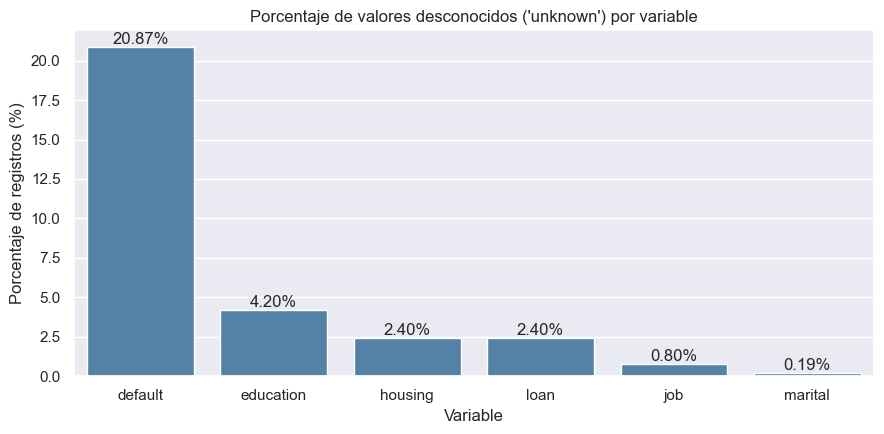

Gráfico guardado en: output_images\01_valores_desconocidos.png

Resumen:
  default     8,597 registros  (20.87%)
  education   1,731 registros  (4.20%)
  housing       990 registros  (2.40%)
  loan          990 registros  (2.40%)
  job           330 registros  (0.80%)
  marital        80 registros  (0.19%)


In [5]:
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x=nulos_unknown.index, y=nulos_unknown["%_unknown"], color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.2f%%")
plt.title("Porcentaje de valores desconocidos ('unknown') por variable")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de registros (%)")
guardar_figura("01_valores_desconocidos.png")

print("\nResumen:")
for var, fila in nulos_unknown.iterrows():
    print(f"  {var:<10} {int(fila['nulos_unknown']):>6,} registros  ({fila['%_unknown']:.2f}%)")

**Observaciones de valores desconocidos**

Hay seis variables categóricas con valores nulos. 
- `default` (mora) concentra el **20.87%** de nulos. Es un volumen demasiado grande para eliminar esas filas sin perder una quinta parte de la muestra.
- `education` presenta un 4.20% de desconocido, `housing` y `loan` un 2.40% cada una, `job` y `marital` están por debajo del 1%. 
- La calidad del atributo de mora (`default`) es la más afectada y dado que es de las más relevantes en banca realizaremos tratamiento adicional en la sección 3 evaluando su relación con la aceptación.

Note que existe una coincidencia de la cantidad de nulos entre `housing` y `loan`, esto amerita una revisión adicional si el grupo de nulos en ambos coincide o es distinto, quedando pendiente para la sección 3.3.

### 2.2 Balance de datos respecto a la aceptación de depósitos

Revisaremos la proporción de clientes que suscribieron el depósito, para evitar sesgos en el análisis por posibles desbalances.

     frecuencia  porcentaje
y                          
no        36548       88.73
yes        4640       11.27

Ratio de desbalance: por cada cliente que suscribe hay 7.88 que no suscriben (1 : 7.88).


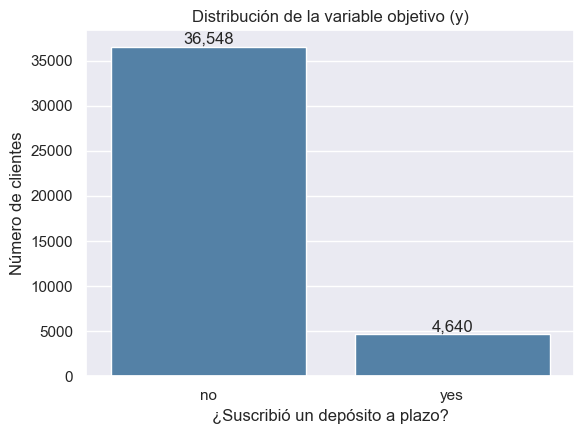

Gráfico guardado en: output_images\02_balance_variable_objetivo.png


In [6]:
balance = tabla_frecuencias(df_original["y"])
print(balance)
ratio = balance.loc["no", "frecuencia"] / balance.loc["yes", "frecuencia"]
print(f"\nRatio de desbalance: por cada cliente que suscribe hay {ratio:.2f} que no suscriben (1 : {ratio:.2f}).")

plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x=df_original["y"], order=["no", "yes"], color="steelblue")
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.title("Distribución de la variable objetivo (y)")
plt.xlabel("¿Suscribió un depósito a plazo?")
plt.ylabel("Número de clientes")
guardar_figura("02_balance_variable_objetivo.png")

**Observaciones del balance de datos**

- Solo el **11.27%** de los clientes contactados suscribió el depósito (4,640 casos), frente a un **88.73%** que no lo hizo (36,548 casos). El ratio es **1 : 7.88**: por cada suscripción hay casi ocho contactos sin éxito.
- Esta cifra cuantifica el problema de negocio, la mayor parte del esfuerzo de la campaña se invierte en clientes que no convierten.
- Ello implicancia que los conteos siempre favorecerán al grupo de clientes que rechazan. Por ello, en el análisis multivariado será conveniente usar **tasas de aceptación** y no conteos.

## 3. Preprocesamiento de los datos

En esta etapa haremos el tratamiento correspondiente según lo observado en la sección anterior (limpieza de duplicados y valores faltantes). Se trabaja sobre una copia para conservar el dataset original.

### 3.1 Valores duplicados

In [7]:
df = df_original.copy()

n_duplicados = df.duplicated().sum()
print(f"Filas completamente duplicadas: {n_duplicados} ({100 * n_duplicados / len(df):.3f}% del total)\n")

df[df.duplicated(keep=False)].sort_values(["age", "duration"]).head(6)

Filas completamente duplicadas: 12 (0.029% del total)



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.80,93.08,-47.10,1.42,"5,099.10",no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.80,93.08,-47.10,1.42,"5,099.10",no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.40,93.92,-42.70,4.96,"5,228.10",no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.40,93.92,-42.70,4.96,"5,228.10",no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.40,93.92,-42.70,4.97,"5,228.10",no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.40,93.92,-42.70,4.97,"5,228.10",no


In [8]:
filas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Filas antes: {filas_antes:,} | Filas después: {len(df):,} | Eliminadas: {filas_antes - len(df)}")

Filas antes: 41,188 | Filas después: 41,176 | Eliminadas: 12


**Observacioenes sobre duplicados**

- Se encontraron **12 filas idénticas** en las 21 variables, incluidos la duración exacta de la llamada, el día, el mes y los cinco indicadores macroeconómicos. Representan apenas el **0.029%** del total.
- El dataset no tiene un identificador de cliente, por lo que no es posible confirmar si son dos personas distintas con características idénticas. Sin embargo, coincidir en todos los atributos, incluida la duración al segundo, es muy improbable y apunta a un error de registro.

Se decidió **eliminarlos**

**Justificación:** Dado que la eliminación no altera las distribuciones, y mantenerlos contaría dos veces el mismo contacto. El dataset de trabajo queda con **41,176 registros**.

### 3.2 Cambio de nombre de las columnas

Las columnas se renombran al español con nombres descriptivos y sin puntos. Esto facilita la lectura del análisis y evita errores al referirse a nombres como `emp.var.rate`.

In [9]:
nombres_columnas = {
    "age": "edad",
    "job": "empleo",
    "marital": "estado_civil",
    "education": "educacion",
    "default": "mora",
    "housing": "vivienda",
    "loan": "prestamo",
    "contact": "tipo_contacto",
    "month": "mes",
    "day_of_week": "dia_semana",
    "duration": "duracion",
    "campaign": "campana",
    "pdays": "dias_previos",
    "previous": "contactos_previos",
    "poutcome": "resultado_previo",
    "emp.var.rate": "tasa_var_empleo",
    "cons.price.idx": "ipc",
    "cons.conf.idx": "icc",
    "euribor3m": "euribor3m",
    "nr.employed": "num_empleados",
    "y": "suscribio",
}
df = df.rename(columns=nombres_columnas)
print(list(df.columns))

['edad', 'empleo', 'estado_civil', 'educacion', 'mora', 'vivienda', 'prestamo', 'tipo_contacto', 'mes', 'dia_semana', 'duracion', 'campana', 'dias_previos', 'contactos_previos', 'resultado_previo', 'tasa_var_empleo', 'ipc', 'icc', 'euribor3m', 'num_empleados', 'suscribio']


### 3.3 Identificación y validación de los valores nulos

En el contexto bancario, datos como la mora o los préstamos provienen de centrales de riesgo y de los sistemas del banco (en Perú la SBS), entonces para decidir sobre a los valores nulos aplicarmos una **validación descriptiva**, comparando la tasa de aceptación en el grupo de nulos con la tasa general y con el rango de tasas en el grupo de mora conocida.

La idea es determinar si el grupo de clientes con mora desconocida contiene información util sobre los clientes que aceptaron el depósito o si solamente es ruido. Si es lo primero añadiremos una categoría nueva y sino imputaremos por moda para no alterar la distribución.

Adicionalmente, dado que encontramos la misma cantidad de nulos entre vivienda(`housing`) y préstamo(`loan`), ello motiva revisar si ¿los nulos de vivienda y préstamo son los mismos registros?

In [10]:
from IPython.display import display
columnas_unknown = ["mora", "educacion", "vivienda", "prestamo", "empleo", "estado_civil"]
tasa_general = 100 * (df["suscribio"] == "yes").mean()
print(f"Tasa general de aceptación: {tasa_general:.2f}%\n")

subcategorias = []
filas = []
for col in columnas_unknown:
    tasas = 100 * pd.crosstab(df[col], df["suscribio"], normalize="index")["yes"]
    conocidas = tasas.drop("unknown")
    filas.append({
        "variable": col,
        "Nulos": (df[col] == "unknown").sum(),
        "% nulos": 100 * (df[col] == "unknown").mean(),
        "Tasa de Nulos subscritos": tasas["unknown"],
        "diferencia porcentual de la tasa general y del grupo": tasas["unknown"] - tasa_general,
    })
    tasas_por_subcategoria = (
        pd.crosstab(df[col], df["suscribio"], normalize="index")["yes"]
        .rename("tasa de aceptación %")
        .to_frame()
        .T
    )*100
    conteo_por_subcategoria = (
        pd.crosstab(df[col], df["suscribio"])
        .T
    )
    conteo_por_subcategoria = pd.concat([tasas_por_subcategoria, conteo_por_subcategoria])
    subcategorias.append(conteo_por_subcategoria)

validacion_unknown = pd.DataFrame(filas).set_index("variable")
display(validacion_unknown.T)

for idx, col in enumerate(columnas_unknown):
    display(subcategorias[idx])

mismas_filas = ((df["vivienda"] == "unknown") == (df["prestamo"] == "unknown")).all()
print(f"\nLos nulos de vivienda y préstamo corresponden a las mismas filas: {mismas_filas}")

Tasa general de aceptación: 11.27%



variable,mora,educacion,vivienda,prestamo,empleo,estado_civil
Nulos,"8,596.00","1,730.00",990.00,990.00,330.00,80.00
% nulos,20.88,4.20,2.40,2.40,0.80,0.19
Tasa de Nulos subscritos,5.15,14.51,10.81,10.81,11.21,15.00
diferencia porcentual de la tasa general y del grupo,-6.11,3.24,-0.46,-0.46,-0.05,3.73


mora,no,unknown,yes
tasa de aceptación %,12.88,5.15,0.00
no,"28,381.00","8,153.00",3.00
yes,"4,196.00",443.00,0.00


educacion,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree,unknown
tasa de aceptación %,10.25,8.21,7.82,10.84,22.22,11.35,13.72,14.51
no,"3,748.00","2,103.00","5,572.00","8,481.00",14.00,"4,645.00","10,495.00","1,479.00"
yes,428.00,188.00,473.00,"1,031.00",4.00,595.00,"1,669.00",251.00


vivienda,no,unknown,yes
tasa de aceptación %,10.88,10.81,11.62
no,"16,590.00",883.00,"19,064.00"
yes,"2,025.00",107.00,"2,507.00"


prestamo,no,unknown,yes
tasa de aceptación %,11.34,10.81,10.93
no,"30,089.00",883.00,"5,565.00"
yes,"3,849.00",107.00,683.00


empleo,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
tasa de aceptación %,12.97,6.90,8.52,10.00,11.22,25.26,10.49,8.14,31.43,10.83,14.20,11.21
no,"9,068.00","8,615.00","1,332.00",954.00,"2,596.00","1,284.00","1,272.00","3,644.00",600.00,"6,009.00",870.00,293.00
yes,"1,351.00",638.00,124.00,106.00,328.00,434.00,149.00,323.00,275.00,730.00,144.00,37.00


estado_civil,divorced,married,single,unknown
tasa de aceptación %,10.32,10.16,14.01,15.00
no,"4,135.00","22,390.00","9,944.00",68.00
yes,476.00,"2,531.00","1,620.00",12.00



Los nulos de vivienda y préstamo corresponden a las mismas filas: True


**Análisis de los valores nulos**

<!-- La tasa general de aceptación es **11.27%**. Frente a ese valor de referencia: -->
Evaluaremos la tasa de aceptación de depósitos entre los grupos de nulos y no nulos para las variables que contenian nulos, dado que los nulos solo existen en variables categoricas y que en los grupos donde no existe un efecto notable con el grupo de nulos, imputaremos por la moda.

En caso se observe una diferencia destacable entre el grupo de con nulos y el resto de subcategorias, imputaremos con una nueva clase para preservar el efecto distinto en el grupo de nulos. 

- En **`mora`** hay 8,596 nulos, de los cuales el **5.15%** han subscrito, menos de la mitad del caso cuando si se conoce la mora (12.88%). La diferencia es de −6.11 puntos porcentuales frente a la tasa general y el grupo es grande. **En el grupo del que se desconoce la mora el % de aceptación cambio notablemete, esto indica que existe un segmento con menor propensión y lo conservaremos imputando una nueva categoria**, posiblemente clientes sin historial en la central de riesgos por lo que los conservaremos como una nueva categoría.

- En **`educacion`** el grupo con nulos (1,730 clientes) tiene una tasa de aceptación de **14.51%**, **que supera a todo el resto de subcategorias resaltantes por lo que asumiremos un nuevo segmento**, en caso de `illiterate` que si supera la tasa de nulos con una tasa de 22.22%, note que apenas tiene 18 clientes por lo que despreciamos que exista alguna diferencia notable de la aceptación con este grupo.

- Respecto a **`vivienda` y `prestamo`** encontramos que los desconocidos (10.81%) están prácticamente en el mismo rango de las categorías sin nulos (10.88% a 11.62%) y en la tasa general. Además, son **los mismos 990 registros** en ambas variables, lo que sugiere una falla puntual de registro y no un segmento de clientes, por ello imputaremos con la moda.

- En **`empleo`** la tasa de aceptación en el grupo con nulo es 11.21%, casi idéntica a la general (se diferencia solo por −0.05 puntos) y afecta al 0.80% de los registros, entonces vemos apropiado imputar con la moda.

- Sobre el **`estado_civil`** la tasa de los desconocidos es (15.00%) relativamente alta, pero se calcula sobre solo **80 clientes** (0.19%). Con tan pocos casos, una diferencia de 12 suscripciones cambia la tasa en varios puntos, por lo que no se considera evidencia de un segmento propio y se imputara con la moda.

### 3.4 Tratamiento de los valores nulos

Con base en la validación anterior, primero se convierten los `"unknown"` en valores nulos (`NaN`), de modo que queden identificados de forma explícita, y luego se tratan según la regla de decisión:

| Variable | Tratamiento | Justificación |
|---|---|---|
| `mora`, `educacion` | Se conservan como categoría `"desconocido"` | Su tasa de aceptación difiere de la de las categorías conocidas: la ausencia del dato describe un segmento de clientes. |
| `empleo`, `estado_civil`, `vivienda`, `prestamo` | Imputación con la moda | Su tasa de aceptación es similar a la del resto y afectan a pocos registros, por lo que la moda no distorsiona la distribución. |

Se prefiere la imputación antes que la eliminación de filas para no perder los datos válidos del resto de variables de esos clientes.

In [11]:
# Pasamos los valores "unknown" a NaN
df = df.replace("unknown", np.nan)
print("Valores nulos por variable después de la conversión:")
print(df.isnull().sum()[df.isnull().sum() > 0], "\n")

for col in ["mora", "educacion"]:
    df[col] = df[col].fillna("desconocido")

for col in ["empleo", "estado_civil", "vivienda", "prestamo"]:
    moda = df[col].mode()[0]
    n_imputados = df[col].isnull().sum()
    df[col] = df[col].fillna(moda)
    print(f"{col:<13} -> {n_imputados:>4} valores imputados con la moda '{moda}'")

print(f"\nValores nulos restantes en el dataset: {df.isnull().sum().sum()}")

Valores nulos por variable después de la conversión:
empleo           330
estado_civil      80
educacion       1730
mora            8596
vivienda         990
prestamo         990
dtype: int64 

empleo        ->  330 valores imputados con la moda 'admin.'
estado_civil  ->   80 valores imputados con la moda 'married'
vivienda      ->  990 valores imputados con la moda 'yes'
prestamo      ->  990 valores imputados con la moda 'no'

Valores nulos restantes en el dataset: 0


### 3.5 Revisión de `dias_previos`

La variable `dias_previos` usa el valor **999** para indicar que el cliente **nunca fue contactado** en una campaña anterior. Este valor no es una cantidad real de días: si se trata como número, eleva de forma artificial la media y oculta la distribución de los clientes que sí fueron contactados.

Por lo tanto aplicaremos un tratamiento de crear una nueva variable `dias_desde_contacto`, igual a `dias_previos` pero con `NaN` cuando el valor es 999. Estos nulos **no se imputan**, porque representan un dato que no aplica (el contacto nunca ocurrió) y cualquier valor inventado sería engañoso. La información de si hubo o no un contacto previo se conserva en una nueva variable categórica (sección 3.7).

In [12]:
nunca_contactados = (df["dias_previos"] == 999).sum()
print(f"Registros con dias_previos = 999: {nunca_contactados:,} ({100 * nunca_contactados / len(df):.2f}%)")

df["dias_desde_contacto"] = df["dias_previos"].where(df["dias_previos"] != 999)
print(f"Registros con días reales desde el último contacto: {df['dias_desde_contacto'].notnull().sum():,}")
print(f"Media de dias_previos con el valor 999:  {df['dias_previos'].mean():.2f}")
print(f"Media de dias_desde_contacto sin el 999: {df['dias_desde_contacto'].mean():.2f}")

Registros con dias_previos = 999: 39,661 (96.32%)
Registros con días reales desde el último contacto: 1,515
Media de dias_previos con el valor 999:  962.46
Media de dias_desde_contacto sin el 999: 6.01


### 3.6 Transformación de tipos de dato

Las variables categóricas se convierten al tipo `category`. En las variables ordinales (`educacion`, `mes`, `dia_semana`) se define el orden natural de sus niveles, lo que permite que tablas y gráficos respeten ese orden. La variable objetivo se recodifica como `"Sí"` / `"No"` para facilitar la lectura.

In [13]:
df["suscribio"] = df["suscribio"].map({"yes": "Sí", "no": "No"})
orden_educacion = ["illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school",
                   "professional.course", "university.degree", "desconocido"]
orden_meses = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
orden_dias = ["mon", "tue", "wed", "thu", "fri"]

df["educacion"] = pd.Categorical(df["educacion"], categories=orden_educacion, ordered=True)
df["mes"] = pd.Categorical(df["mes"], categories=orden_meses, ordered=True)
df["dia_semana"] = pd.Categorical(df["dia_semana"], categories=orden_dias, ordered=True)

for col in ["empleo", "estado_civil", "mora", "vivienda", "prestamo",
            "tipo_contacto", "resultado_previo", "suscribio"]:
    df[col] = df[col].astype("category")

print(df.dtypes)

edad                      int64
empleo                 category
estado_civil           category
educacion              category
mora                   category
vivienda               category
prestamo               category
tipo_contacto          category
mes                    category
dia_semana             category
duracion                  int64
campana                   int64
dias_previos              int64
contactos_previos         int64
resultado_previo       category
tasa_var_empleo         float64
ipc                     float64
icc                     float64
euribor3m               float64
num_empleados           float64
suscribio              category
dias_desde_contacto     float64
dtype: object


### 3.7 Enriquecimiento de los datos: creación de nuevas variables

Se crearán nuevas variables derivadas de acuerdo con los objetivos propuestos en la sección 1.2, mediante reglas simples que faciliten la interpretación de los datos y permitan identificar patrones relevantes para el negocio:

**Descripción**
| Nueva variable | Regla | Propósito |
|---|---|---|
| `duracion_min` | `duracion / 60` | Expresar la duración de la llamada en minutos, una unidad más intuitiva. |
| `tramo_duracion` | Intervalos de minutos con `pd.cut` | Identificar a partir de qué duración aumenta la aceptación. |
| `grupo_etario` | Intervalos de edad con `pd.cut` | Perfilar etapas de vida del cliente. |
| `contacto_previo` | `"Sí"` si `dias_previos` ≠ 999 | Distinguir a los clientes con historial de contacto. |

**Justificación**
* **`duracion_min`:** Convertir la duración de las llamadas a minutos facilita su interpretación y permite describir las características del contacto en una unidad más intuitiva.
* **`tramo_duracion`:** Agrupar las llamadas según su duración permite comparar las tasas de aceptación entre intervalos e identificar posibles patrones de conversión asociados al tiempo de contacto.
* **`grupo_etario`:** Clasificar a los clientes en grupos de edad facilita la descripción de su perfil y la comparación de las tasas de aceptación entre distintas etapas de vida.
* **`contacto_previo`:** Distinguir a los clientes que tuvieron contactos anteriores de aquellos sin contacto previo permite evaluar si el historial de interacción se asocia con diferencias en la aceptación del depósito a plazo.


In [14]:
# Duración en minutos
df["duracion_min"] = df["duracion"] / 60

# Tramos de duración de la llamada (minutos)
df["tramo_duracion"] = pd.cut(
    df["duracion_min"],
    bins=[0, 1, 2, 3, 5, 10, df["duracion_min"].max()],
    labels=["0-1 min", "1-2 min", "2-3 min", "3-5 min", "5-10 min", "más de 10 min"],
    include_lowest=True,
)

# Grupos etarios
df["grupo_etario"] = pd.cut(
    df["edad"],
    bins=[16, 24, 34, 44, 54, 64, df["edad"].max()],
    labels=["17-24", "25-34", "35-44", "45-54", "55-64", "65 o más"],
)

# Indicador de contacto en campañas anteriores
df["contacto_previo"] = np.where(df["dias_previos"] != 999, "Sí", "No")
df["contacto_previo"] = df["contacto_previo"].astype("category")

for col in ["tramo_duracion", "grupo_etario", "contacto_previo"]:
    print(f"\n{col}:")
    print(tabla_frecuencias(df[col]).sort_index())


tramo_duracion:
                frecuencia  porcentaje
tramo_duracion                        
0-1 min               4284       10.40
1-2 min               8628       20.95
2-3 min               7784       18.90
3-5 min               9278       22.53
5-10 min              7738       18.79
más de 10 min         3464        8.41

grupo_etario:
              frecuencia  porcentaje
grupo_etario                        
17-24               1067        2.59
25-34              13684       33.23
35-44              13495       32.77
45-54               8702       21.13
55-64               3566        8.66
65 o más             662        1.61

contacto_previo:
                 frecuencia  porcentaje
contacto_previo                        
No                    39661       96.32
Sí                     1515        3.68


In [15]:
print(f"Dimensiones finales: {df.shape[0]:,} filas x {df.shape[1]} columnas\n")
df.info()

Dimensiones finales: 41,176 filas x 26 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   edad                 41176 non-null  int64   
 1   empleo               41176 non-null  category
 2   estado_civil         41176 non-null  category
 3   educacion            41176 non-null  category
 4   mora                 41176 non-null  category
 5   vivienda             41176 non-null  category
 6   prestamo             41176 non-null  category
 7   tipo_contacto        41176 non-null  category
 8   mes                  41176 non-null  category
 9   dia_semana           41176 non-null  category
 10  duracion             41176 non-null  int64   
 11  campana              41176 non-null  int64   
 12  dias_previos         41176 non-null  int64   
 13  contactos_previos    41176 non-null  int64   
 14  resultado_previo     

**Resumen**

- **Duplicados:** se eliminaron 12 filas, el dataset pasó de 41,188 a **41,176 registros**.
- **Valores nulos:** los "unknown" se convirtieron en `NaN` y se trataron según la validación. `mora` y `educacion` conservan la categoría `"desconocido"`. En las otras cuatro variables se imputó la moda: `admin.` (330 valores en `empleo`), `married` (80 en `estado_civil`), `yes` (990 en `vivienda`) y `no` (990 en `prestamo`). Tras este paso no quedan nulos en las variables originales.
- **Dias previos:** el 96.32% de los clientes nunca había sido contactado (`dias_previos` = 999). Al separar ese valor, la media de días desde el último contacto pasa de un engañoso **962.46** a un valor real de **6.01 días**, calculado sobre los 1,515 clientes con historial. Los únicos nulos del dataset final (39,661 en `dias_desde_contacto`) son intencionales: el dato no aplica.
- **Tipos de dato:** 14 variables quedaron como `category`; `educacion`, `mes` y `dia_semana` tienen un orden definido.
- **Nuevas variables:**
  - Por duración, el tramo más frecuente es "3-5 min" (22.53%) y solo el 8.41% de las llamadas supera los 10 minutos.
  - Los grupos etarios dominantes son 25-34 (33.23%) y 35-44 (32.77%).
  - Solo el 3.68% de los clientes tiene contacto previo.
- El dataset preprocesado tiene **41,176 filas y 26 columnas**.

## 4. Análisis exploratorio de datos (EDA)

Variables numéricas analizadas:

In [16]:
variables_numericas = ["edad", "duracion_min", "campana", "dias_desde_contacto", "contactos_previos",
                       "tasa_var_empleo", "ipc", "icc", "euribor3m", "num_empleados"]

variables_categoricas_perfil = ["empleo", "estado_civil", "educacion", "mora", "vivienda", "prestamo", "grupo_etario"]
variables_categoricas_campana = ["tipo_contacto", "mes", "dia_semana", "resultado_previo", "contacto_previo"]

print("Numéricas:", variables_numericas)
print("Categóricas de perfil:", variables_categoricas_perfil)
print("Categóricas de campaña:", variables_categoricas_campana)

Numéricas: ['edad', 'duracion_min', 'campana', 'dias_desde_contacto', 'contactos_previos', 'tasa_var_empleo', 'ipc', 'icc', 'euribor3m', 'num_empleados']
Categóricas de perfil: ['empleo', 'estado_civil', 'educacion', 'mora', 'vivienda', 'prestamo', 'grupo_etario']
Categóricas de campaña: ['tipo_contacto', 'mes', 'dia_semana', 'resultado_previo', 'contacto_previo']


Nota: `dias_desde_contacto` solo tiene valores para los clientes contactados en campañas anteriores, por lo que sus estadísticas se calculan sobre ese subconjunto. La duración se analiza en minutos (`duracion_min`).

### 4.a Análisis univariado

#### 4.a.1 Medidas de tendencia central y de dispersión

**Nota**: Añadiremos una asunción para determinar los valores atípicos, para cada variable según la distribución los valores fuera del rango (-1.5·IQR, 1.5·IQR) se consideran atípicos.

In [18]:
resumen = resumen_numerico(df, variables_numericas)

print("Medidas de tendencia central:")
print(resumen[["n", "media", "mediana", "moda"]].round(2))
print("\nMedidas de dispersión:")
print(resumen[["desv_est", "varianza", "minimo", "q1", "q3", "maximo", "rango", "iqr"]].round(2))
print("\nAtípicos según IQR:")
print(resumen[["lim_inf_iqr", "lim_sup_iqr", "n_atipicos", "pct_atipicos"]].round(2))

Medidas de tendencia central:
                         n    media  mediana     moda
variable                                             
edad                 41176    40.02    38.00    31.00
duracion_min         41176     4.31     3.00     1.42
campana              41176     2.57     2.00     1.00
dias_desde_contacto   1515     6.01     6.00     3.00
contactos_previos    41176     0.17     0.00     0.00
tasa_var_empleo      41176     0.08     1.10     1.40
ipc                  41176    93.58    93.75    93.99
icc                  41176   -40.50   -41.80   -36.40
euribor3m            41176     3.62     4.86     4.86
num_empleados        41176 5,167.03 5,191.00 5,228.10

Medidas de dispersión:
                     desv_est  varianza   minimo       q1       q3   maximo  rango    iqr
variable                                                                                 
edad                    10.42    108.59    17.00    32.00    47.00    98.00  81.00  15.00
duracion_min             4.3

**Observaciones de la tendencia central y dispersión**

| Variable | Hallazgos |
|---|---|
| `edad` | Media de 40.02 años, mediana de 38 y moda de 31: la media supera a la mediana por la presencia de clientes mayores. La desviación estándar es de 10.42 años y el 50% central está entre 32 y 47 años (IQR = 15). Hay 468 atípicos (1.14%), todos por encima de 69.5 años. |
| `duracion_min` | La media de 4.31 minutos supera a la mediana de 3.00: la mayoría de llamadas es corta, pero hay llamadas muy largas. El rango (81.97 min) es enorme frente al IQR (3.62 min). El 7.20% de las llamadas (2,963) supera los 10.74 minutos y se considera atípica. |
| `campaña` | La moda es 1 contacto y la mediana, 2. La media (2.57) se eleva por un grupo reducido de clientes contactados de forma reiterada, hasta 56 veces. El 5.84% (2,406 clientes) recibió más de 6 contactos, este seria el segmento de **insistencia excesiva**. |
| `dias_desde_contacto` | Para los 1,515 clientes con historial, la media (6.01) y la mediana (6) casi coinciden, con un IQR de 3 a 7 días. Los contactos previos suelen ser recientes, alrededor de una semana antes. El 5.41% supera los 13 días. |
| `contactos_previos` | La media es 0.17 y la moda, 0. El IQR es 0 porque más del 75% de los clientes nunca fue contactado, por eso según IQR **cualquier** cliente con al menos un contacto previo (13.66%) es atípico. En este caso no se trata de errores, sino del grupo minoritario con historial. |
| `tasa_var_empleo` | Varia en un rango de −3.4 a 1.4, sin atípicos. La mediana (1.10) es muy superior a la media (0.08): indica la existencia periodos de crecimiento y decrecimiento del empleo. |
| `ipc` | Tiene muy poca dispersión (desviación estándar de 0.58 sobre una media de 93.58; rango de 2.57 puntos). Es la variable más estable del grupo. |
| `icc` | Media de −40.50 y mediana de −41.80: la confianza del consumidor fue negativa en todo el periodo, reflejo del contexto de crisis. Hay 446 atípicos (1.08%) en el extremo menos pesimista (−26.9). |
| `euribor3m` | La mediana (4.86%) está muy por encima de la media (3.62%) y la desviación estándar es alta (1.73) para una tasa de interés. Esto evidencia dos contextos distintos: tasas previas a la crisis cercanas a 5% y tasas posteriores cercanas a 1%. |
| `num_empleados` | Media de 5,167 y mediana de 5,191, con un IQR de 129. No presenta atípicos, pero su distribución está concentrada en un rango pequeño de valores. |

En síntesis, las variables que describen las llamadas (`duracion_min`, `campana`, `contactos_previos`) presentan la mayor dispersión respecto al resto y concentran los valores extremos. Las variables macroeconómicas no tienen atípicos, pero su gran diferencia entre media y mediana es un indicador que poseen distribuciones sesgadas.

#### 4.a.2 Boxplots de las variables numéricas

Validaremos el análisis de dispersión previo visualizando los boxplots respectivos.

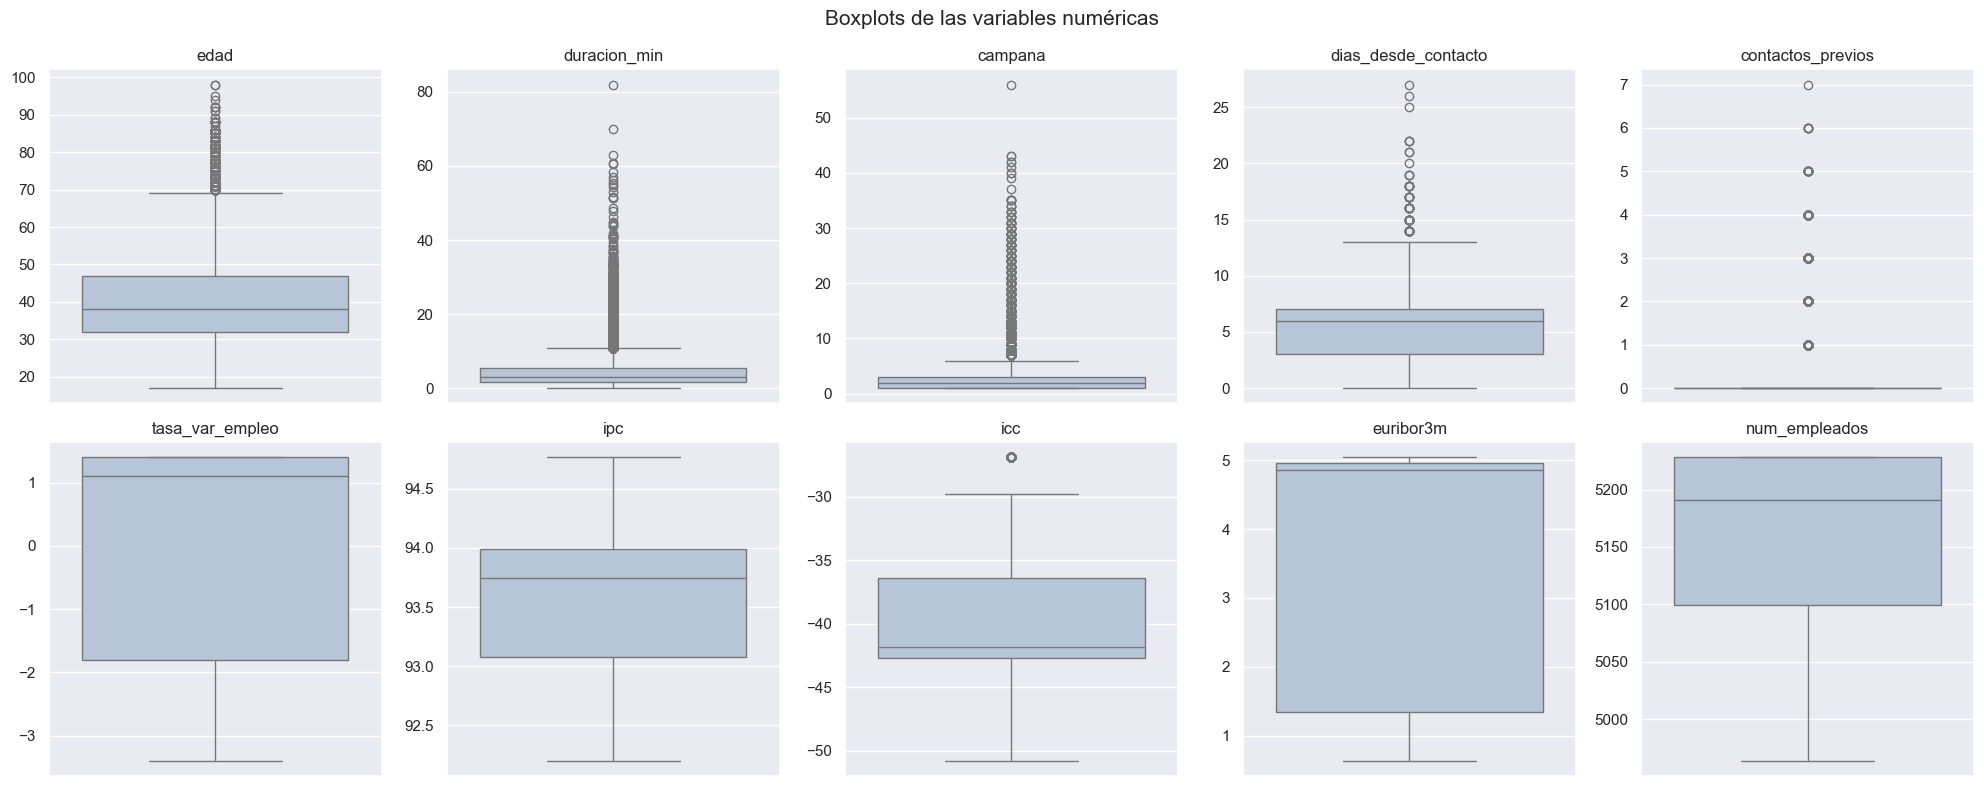

Gráfico guardado en: output_images\03_boxplots_variables_numericas.png

Resumen:
                      minimo       q1  mediana       q3   maximo  n_atipicos  pct_atipicos
variable                                                                                  
edad                   17.00    32.00    38.00    47.00    98.00         468          1.14
duracion_min            0.00     1.70     3.00     5.32    81.97        2963          7.20
campana                 1.00     1.00     2.00     3.00    56.00        2406          5.84
dias_desde_contacto     0.00     3.00     6.00     7.00    27.00          82          5.41
contactos_previos       0.00     0.00     0.00     0.00     7.00        5625         13.66
tasa_var_empleo        -3.40    -1.80     1.10     1.40     1.40           0          0.00
ipc                    92.20    93.08    93.75    93.99    94.77           0          0.00
icc                   -50.80   -42.70   -41.80   -36.40   -26.90         446          1.08
euribor3m

In [25]:
fig, ejes = plt.subplots(2, 5, figsize=(20, 8))
for eje, col in zip(ejes.flatten(), variables_numericas):
    sns.boxplot(y=df[col], ax=eje, color="lightsteelblue")
    eje.set_title(f"{col}")
    eje.set_ylabel('')
plt.suptitle("Boxplots de las variables numéricas", fontsize=15)
guardar_figura("03_boxplots_variables_numericas.png")

cinco_numeros = resumen[["minimo", "q1", "mediana", "q3", "maximo", "n_atipicos", "pct_atipicos"]]
print("\nResumen:")
print(cinco_numeros.round(2))

**Análisis de boxplots**

- **`edad`**: la caja entre 32 y 47 años muestra una base concentrada en adultos en edad laboral. Los puntos por encima de 69.5 años (468 clientes) no son errores: corresponden a jubilados, un segmento pequeño pero relevante para un producto de ahorro de bajo riesgo.
- **`duracion_min`**: caja muy estrecha (1.70 a 5.32 min) y un bigote superior con una larga serie de atípicos hasta 82 minutos. La mayoría de las conversaciones es breve; las largas son excepcionales y, como se verá en el análisis multivariado, están muy asociadas a la aceptación.
- **`campana`**: la mediana está en 2 contactos y la caja llega solo hasta 3. Los atípicos, hasta 56 contactos, representan clientes a los que se insistió de forma desproporcionada, un costo operativo sin respaldo en la conversión.
- **`dias_desde_contacto`**: distribución compacta entre 3 y 7 días ello implica que se suele terminar el contacto en un rango de una semana, con atípicos a partir de 14 días.
- **`contactos_previos`**: la caja colapsa en 0 y todos los valores positivos aparecen como atípicos. Esto ilustra una limitación del filtro por IQR cuando una variable tiene un valor extremadamente frecuente, posiblemente el foco en las campañas es contactar clientes nuevos, pero por la baja tasa de aceptación también denota que se analizo a clientes sin historial y ello potencialmente conllevo a no tener éxito en las campañas.
- **Indicadores macroeconómicos**: ninguno presenta atípicos. En `tasa_var_empleo`, `euribor3m` y `num_empleados` la mediana está pegada al borde superior de la caja: la mayoría de los contactos se hizo en un contexto de tasas y empleo altos, y una minoría relevante, en el contexto opuesto.

**Tratamiento sobre los atípicos:** no se eliminan. En `duracion_min`, `campana` y `edad` los valores extremos son plausibles y contienen información de negocio (llamadas exitosas, insistencia, jubilados). Eliminarlos borraría precisamente los casos que más interesa entender.

#### 4.a.3 Histogramas de las variables numéricas

El histograma muestra la distribución de frecuencias. La forma de la distribución se describe visualmente y se apoya en la comparación entre la media y la mediana: cuando la media es mayor que la mediana, la distribución tiene una cola hacia valores altos.

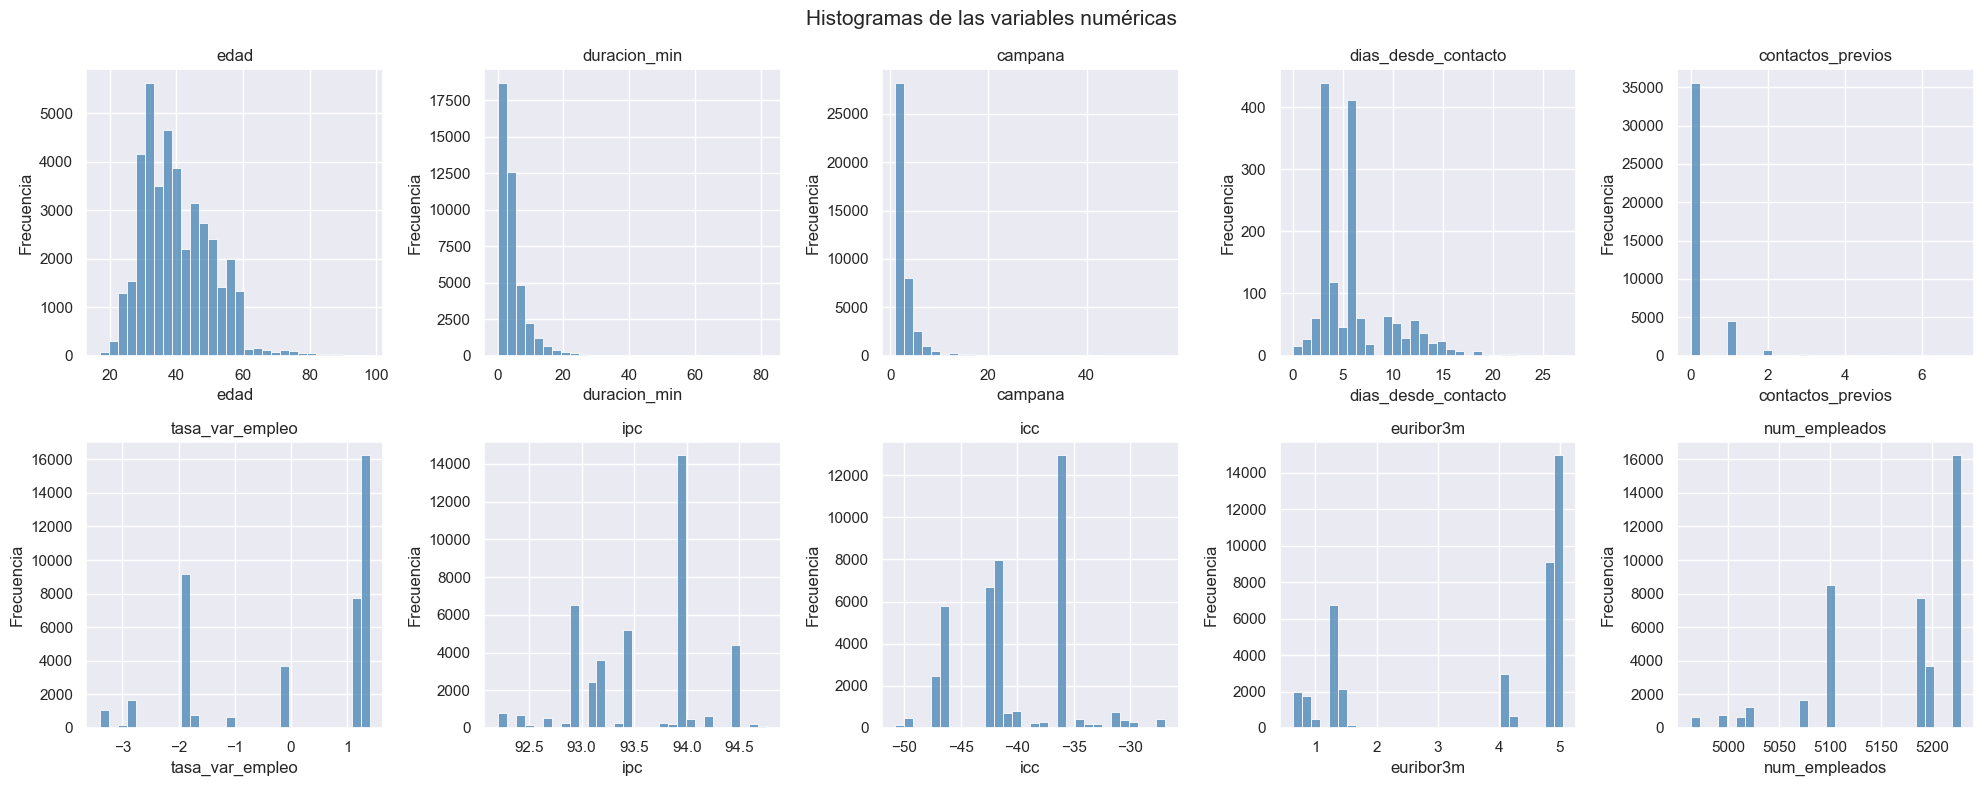

Gráfico guardado en: output_images\04_histogramas_variables_numericas.png

Comparación media vs. mediana y número de valores distintos:
                       media  mediana  media_menos_mediana  valores_distintos
variable                                                                     
edad                   40.02    38.00                 2.02                 78
duracion_min            4.31     3.00                 1.31               1544
campana                 2.57     2.00                 0.57                 42
dias_desde_contacto     6.01     6.00                 0.01                 26
contactos_previos       0.17     0.00                 0.17                  8
tasa_var_empleo         0.08     1.10                -1.02                 10
ipc                    93.58    93.75                -0.17                 26
icc                   -40.50   -41.80                 1.30                 26
euribor3m               3.62     4.86                -1.24                316
num_em

In [29]:
fig, ejes = plt.subplots(2, 5, figsize=(20, 8))
for eje, col in zip(ejes.flatten(), variables_numericas):
    sns.histplot(x=df[col].dropna(), bins=30, ax=eje, color="steelblue")
    eje.set_title(f"{col}")
    eje.set_xlabel(col)
    eje.set_ylabel("Frecuencia")
plt.suptitle("Histogramas de las variables numéricas", fontsize=15)
guardar_figura("04_histogramas_variables_numericas.png")

forma = pd.DataFrame({
    "media": resumen["media"],
    "mediana": resumen["mediana"],
    "media_menos_mediana": resumen["media"] - resumen["mediana"],
    "valores_distintos": [df[col].nunique() for col in variables_numericas],
})
print("\nComparación media vs. mediana y número de valores distintos:")
print(forma.round(2))

In [30]:
clases_edad = pd.cut(df["edad"], bins=range(10, 110, 10), right=False)
print("Tabla de frecuencias de la edad por clases de 10 años:")
print(tabla_frecuencias(clases_edad).sort_index().round(2))

print("\nTabla de frecuencias de campana (primeros valores):")
print(tabla_frecuencias(df["campana"]).sort_index().head(10).round(2))

Tabla de frecuencias de la edad por clases de 10 años:
           frecuencia  porcentaje
edad                             
[10, 20)           75        0.18
[20, 30)         5592       13.58
[30, 40)        16933       41.12
[40, 50)        10523       25.56
[50, 60)         6861       16.66
[60, 70)          724        1.76
[70, 80)          318        0.77
[80, 90)          140        0.34
[90, 100)          10        0.02

Tabla de frecuencias de campana (primeros valores):
         frecuencia  porcentaje
campana                        
1             17634       42.83
2             10568       25.67
3              5340       12.97
4              2650        6.44
5              1599        3.88
6               979        2.38
7               629        1.53
8               400        0.97
9               283        0.69
10              225        0.55


**Análisis de histogramas**

- **`edad`**: distribución con cola hacia la derecha (media 40.02 > mediana 38). La tabla por clases muestra que el **41.12%** de los clientes tiene entre 30 y 39 años y el **80.26%**, entre 20 y 49. Los mayores de 60 años suman menos del 3%. La campaña se dirigió principalmente a adultos jóvenes y de mediana edad.
- **`duracion_min`**: fuerte asimetría hacia la derecha. La frecuencia cae de forma rápida después de los primeros minutos y aparece una cola larga (media 4.31 > mediana 3.00). La mayoría de las llamadas se resuelve rápido, probablemente con un rechazo temprano.
- **`campana`**: también muy asimétrica a la derecha. El **42.83%** de los clientes recibió un solo contacto, el 25.67% dos y el 12.97% tres. A partir de ahí la frecuencia disminuye progresivamente, pero la cola se extiende hasta 56 contactos.
- **`dias_desde_contacto`**: los valores se concentran alrededor de 3 y de 6 días, con una segunda zona menor entre 10 y 15 días. La media y la mediana prácticamente coinciden (6.01 y 6).
- **`contactos_previos`**: casi toda la masa está en 0 y la frecuencia desciende de forma abrupta en 1 y 2 contactos.
- **Indicadores macroeconómicos**: no tienen una forma continua, sino **barras aisladas**, porque toman pocos valores distintos (10 en `tasa_var_empleo`, 11 en `num_empleados` y 26 en `ipc` e `icc`). Posiblemte se debe a que son indicadores trimestrales o mensuales repetidos para todos los clientes contactados en un mismo periodo. En `euribor3m` (316 valores) se observan **dos zonas separadas**: una por debajo de 2% y otra por encima de 4%, con muy pocos datos intermedios. Son los regímenes de tasas bajas y altas señalados en el análisis de dispersión.

**Implicancia:** las variables macroeconómicas funcionan en la práctica como indicadores del **periodo** en que se realizó el contacto más que como mediciones continuas del cliente. Esto conlleva a que sus relaciones con la aceptación deben asumirse como diferencias entre contextos económicos, no entre personas.

#### 4.a.4 Gráficos de barras y tablas de frecuencia de las variables categóricas

Para cada variable categórica se calcula la tabla de frecuencia absoluta y relativa, y se grafica con un gráfico de barras ordenado de mayor a menor frecuencia (salvo en las variables ordinales, que respetan su orden natural).

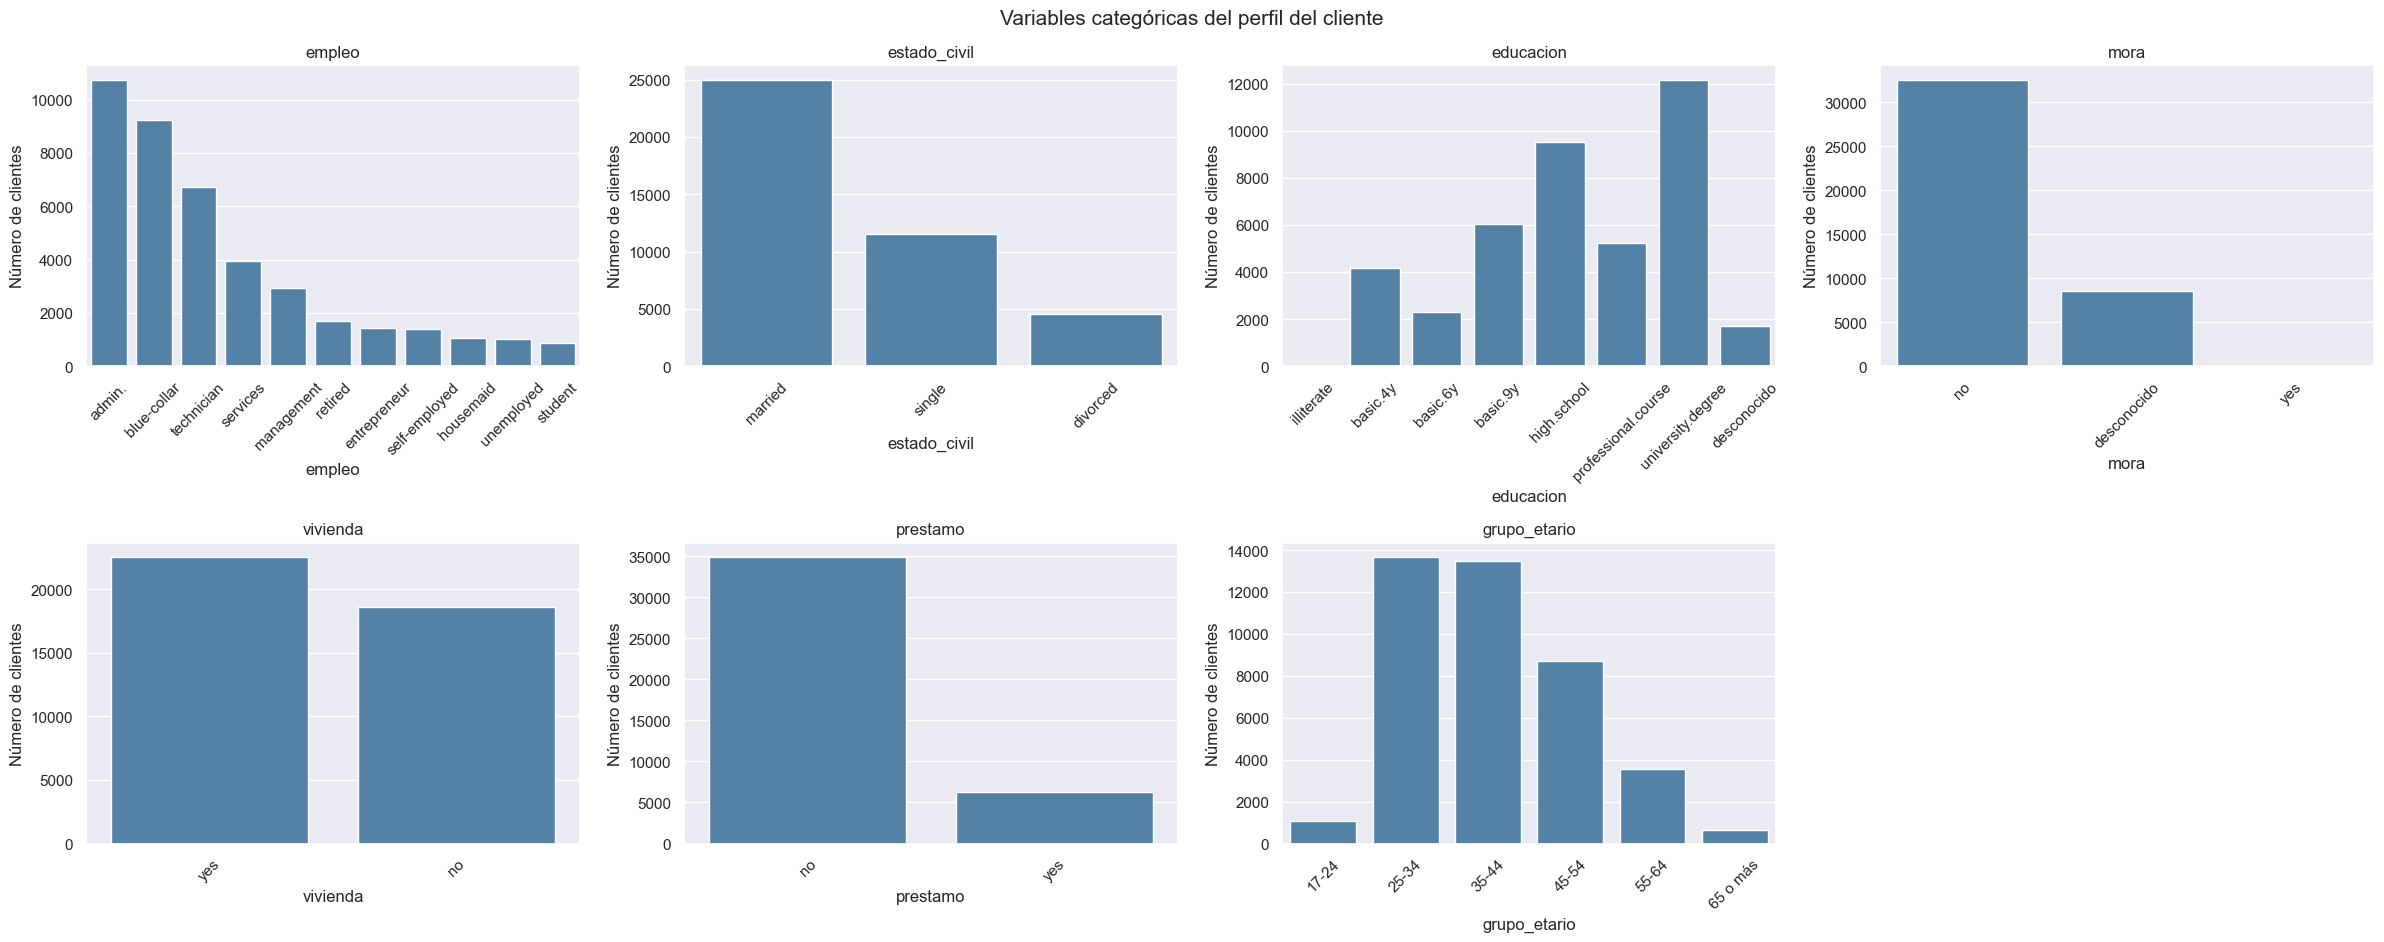

Gráfico guardado en: output_images\05_barras_categoricas_perfil.png

empleo  (categoría dominante: 'admin.' con 26.11%)
               frecuencia  porcentaje
empleo                               
admin.              10749       26.11
blue-collar          9253       22.47
technician           6739       16.37
services             3967        9.63
management           2924        7.10
retired              1718        4.17
entrepreneur         1456        3.54
self-employed        1421        3.45
housemaid            1060        2.57
unemployed           1014        2.46
student               875        2.13

estado_civil  (categoría dominante: 'married' con 60.72%)
              frecuencia  porcentaje
estado_civil                        
married            25001       60.72
single             11564       28.08
divorced            4611       11.20

educacion  (categoría dominante: 'university.degree' con 29.54%)
                     frecuencia  porcentaje
educacion                       

In [32]:
def grafico_barras_categoricas(datos, columnas, nombre_archivo, titulo, filas, cols):
    """Grafica un countplot por variable categórica e imprime su tabla de frecuencias."""
    fig, ejes = plt.subplots(filas, cols, figsize=(6 * cols, 4.8 * filas))
    ejes = ejes.flatten()
    for eje, col in zip(ejes, columnas):
        orden = (datos[col].cat.categories if datos[col].cat.ordered
                 else datos[col].value_counts().index)
        sns.countplot(x=datos[col], order=orden, ax=eje, color="steelblue")
        eje.set_title(f"{col}")
        eje.set_xlabel(col)
        eje.set_ylabel("Número de clientes")
        eje.tick_params(axis="x", rotation=45)
    for eje in ejes[len(columnas):]:
        eje.set_visible(False)
    plt.suptitle(titulo, fontsize=15)
    guardar_figura(nombre_archivo)

    for col in columnas:
        tabla = tabla_frecuencias(datos[col])
        print(f"\n{col}  (categoría dominante: '{tabla.index[0]}' con {tabla['porcentaje'].iloc[0]:.2f}%)")
        print(tabla.round(2))


grafico_barras_categoricas(df, variables_categoricas_perfil, "05_barras_categoricas_perfil.png",
                           "Variables categóricas del perfil del cliente", filas=2, cols=4)

**Observaciones de los gráficos de barras sobre el perfil de los clientes**

- **`empleo`**: tres categorías concentran el **64.95%** de los contactos: `admin.` (26.11%), `blue-collar` (22.47%) y `technician` (16.37%). Estudiantes (2.13%), desempleados (2.46%) y jubilados (4.17%) son grupos minoritarios.
- **`estado_civil`**: predominan los casados (**60.72%**), seguidos de solteros (28.08%) y divorciados (11.20%).
- **`educacion`**: el nivel más frecuente es el universitario (**29.54%**), seguido de secundaria completa (23.10%). La categoría `illiterate` es atípica por su tamaño (18 clientes, 0.04%): cualquier porcentaje calculado sobre ella debe leerse con cautela.
- **`mora`**: la categoría `yes` tiene solo **3 clientes (0.01%)**, prácticamente inexistente. En la práctica, la variable distingue entre `no` (79.12%) y `desconocido` (20.88%).
- **`vivienda`**: el 54.79% tiene préstamo hipotecario, lo que muestra que más de la mitad de los clientes contactados ya tiene un compromiso financiero de largo plazo.
- **`prestamo`**: el 84.83% no tiene préstamo personal.
- **`grupo_etario`**: los grupos de 25-34 (33.23%) y 35-44 años (32.77%) concentran dos tercios de los contactos. Los extremos, 17-24 (2.59%) y 65 o más (1.61%), son poco frecuentes.

**Implicancia:** la campaña contactó mayoritariamente a adultos casados con empleo administrativo, técnico u obrero. Los grupos minoritarios (estudiantes, jubilados y clientes de 65 años o más) reciben pocos contactos. En el análisis multivariado se verifica si ese bajo contacto coincide o no con una baja aceptación.

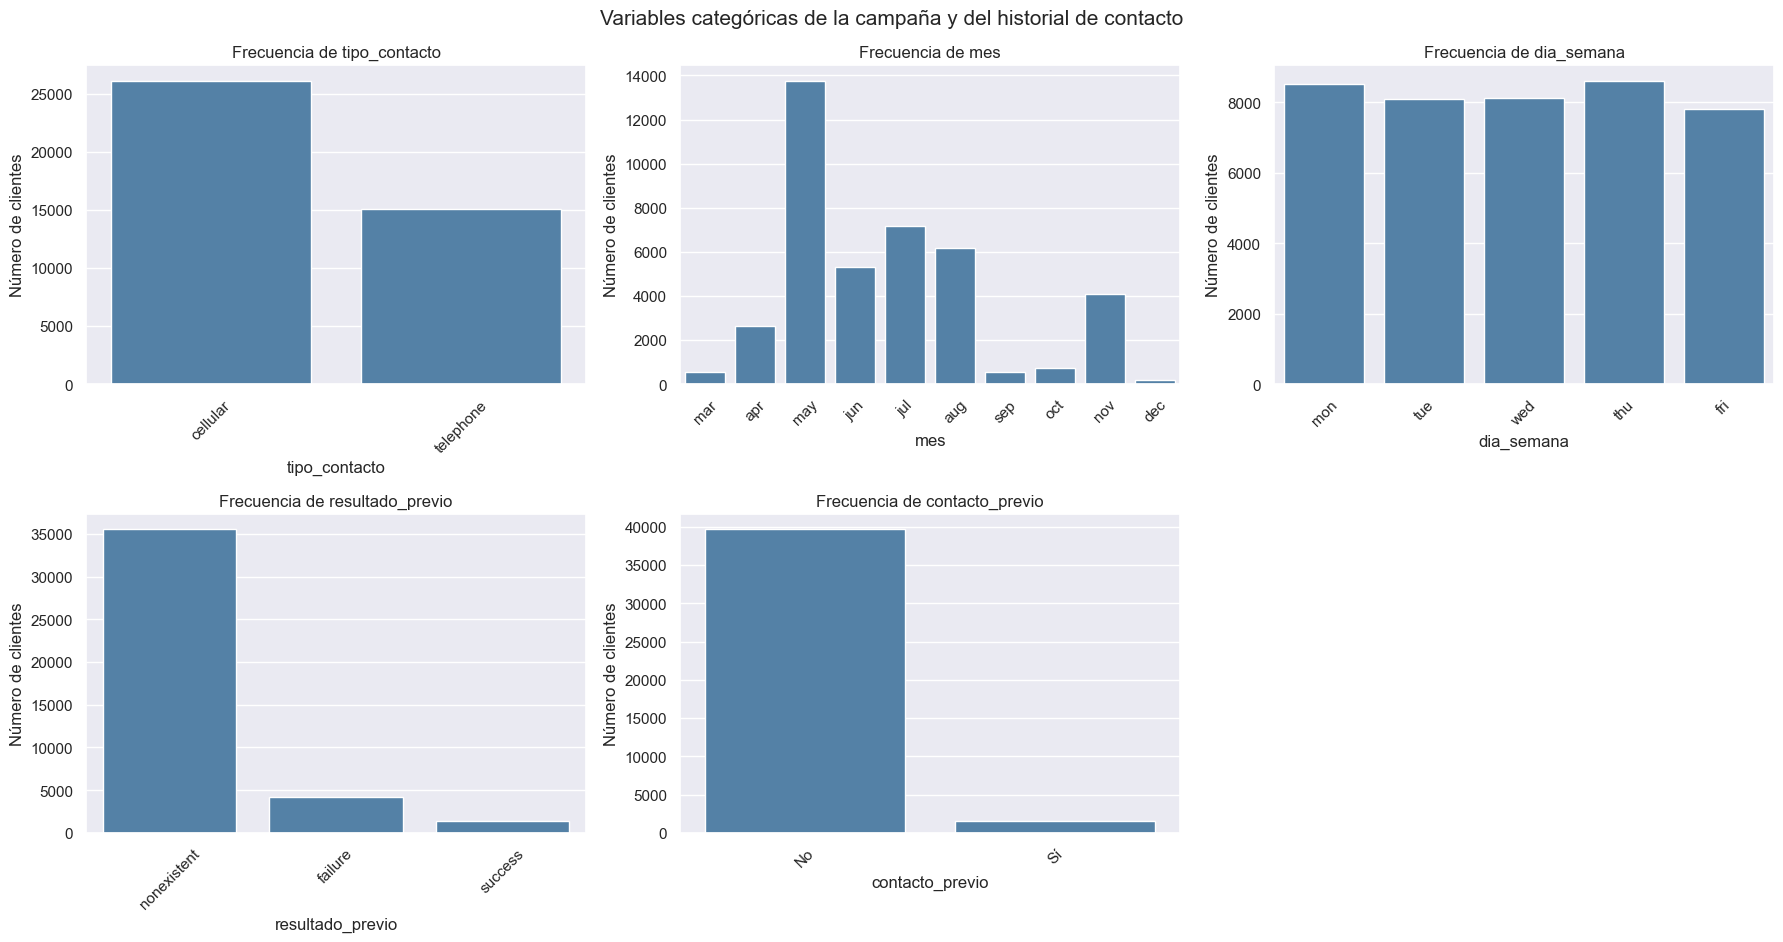

Gráfico guardado en: output_images\06_barras_categoricas_campana.png

tipo_contacto  (categoría dominante: 'cellular' con 63.47%)
               frecuencia  porcentaje
tipo_contacto                        
cellular            26135       63.47
telephone           15041       36.53

mes  (categoría dominante: 'may' con 33.43%)
     frecuencia  porcentaje
mes                        
may       13767       33.43
jul        7169       17.41
aug        6176       15.00
jun        5318       12.92
nov        4100        9.96
apr        2631        6.39
oct         717        1.74
sep         570        1.38
mar         546        1.33
dec         182        0.44

dia_semana  (categoría dominante: 'thu' con 20.93%)
            frecuencia  porcentaje
dia_semana                        
thu               8618       20.93
mon               8512       20.67
wed               8134       19.75
tue               8086       19.64
fri               7826       19.01

resultado_previo  (categoría dominant

In [25]:
grafico_barras_categoricas(df, variables_categoricas_campana, "06_barras_categoricas_campana.png",
                           "Variables categóricas de la campaña y del historial de contacto", filas=2, cols=3)

**Observaciones de los gráficos de barras sobre las campañas**

- **`tipo_contacto`**: el **63.47%** de los contactos se hizo por celular y el 36.53% por teléfono fijo.
- **`mes`**: la campaña está muy concentrada en el tiempo. **Mayo acumula el 33.43%** de los contactos, y mayo, julio, agosto y junio suman el **78.76%**. En cambio, marzo (1.33%), septiembre (1.38%), octubre (1.74%) y diciembre (0.44%) tienen muy poca actividad. No hay registros de enero ni febrero.
- **`dia_semana`**: distribución prácticamente uniforme entre lunes y viernes (19.01% a 20.93%). El día de la semana no refleja una estrategia diferenciada de la campaña.
- **`resultado_previo`**: el **86.34%** de los clientes no participó en campañas anteriores (`nonexistent`). Solo el 3.33% tuvo un resultado previo exitoso.
- **`contacto_previo`**: el 96.32% no había sido contactado antes, lo que confirma que la base es mayoritariamente nueva para el banco en términos de campañas.

**Implicancia:** la operación se concentró en pocos meses de alta actividad y en clientes sin historial. La variable que distingue a un cliente con historial exitoso afecta solo a 1,373 personas; si ese grupo muestra una aceptación alta, representará una oportunidad pequeña en volumen pero muy eficiente.

### 4.b Análisis multivariado

Para el análisis de relaciones entre variables numéricas se usan las nueve variables disponibles para todos los clientes. Se excluye `dias_desde_contacto`, porque solo existe para el 3.7% de los clientes y compararla con las demás mezclaría subconjuntos distintos.

#### 4.b.1 Covarianza

In [33]:
variables_relacion = ["edad", "duracion_min", "campana", "contactos_previos",
                      "tasa_var_empleo", "ipc", "icc", "euribor3m", "num_empleados"]

matriz_covarianza = df[variables_relacion].cov()
print("Matriz de covarianza (la diagonal contiene las varianzas):")
print(matriz_covarianza.round(3))

Matriz de covarianza (la diagonal contiene las varianzas):
                    edad  duracion_min  campana  contactos_previos  tasa_var_empleo   ipc   icc  euribor3m  num_empleados
edad              108.59         -0.04     0.13               0.13            -0.00  0.01  6.22       0.20         -13.26
duracion_min       -0.04         18.68    -0.86               0.04            -0.19  0.01 -0.16      -0.25         -13.95
campana             0.13         -0.86     7.67              -0.11             0.66  0.20 -0.17       0.65          28.85
contactos_previos   0.13          0.04    -0.11               0.24            -0.33 -0.06 -0.12      -0.39         -17.93
tasa_var_empleo    -0.00         -0.19     0.66              -0.33             2.47  0.70  1.43       2.65         102.94
ipc                 0.01          0.01     0.20              -0.06             0.70  0.34  0.16       0.69          21.83
icc                 6.22         -0.16    -0.17              -0.12             1.43  0.

**Análisis de la covarianza**

- La diagonal contiene las varianzas: destaca la de `num_empleados` (5,220.26), muy superior al resto por la escala de la variable (miles de empleados), y la de `edad` (108.59).
- **Signo de las relaciones:**
  - Los indicadores macroeconómicos tienen **covarianzas positivas entre sí**: `tasa_var_empleo` con `euribor3m` (2.65), con `num_empleados` (102.94) y con `ipc` (0.70); `euribor3m` con `num_empleados` (118.44). Tienden a subir y bajar juntos.
  - `contactos_previos` tiene **covarianza negativa** con los indicadores macroeconómicos (−0.39 con `euribor3m` y −17.93 con `num_empleados`). Los clientes con más contactos previos se concentran en los periodos de tasas y empleo bajos.
  - `duracion_min` y `campana` covarían negativamente (−0.86): los clientes que recibieron más contactos tienden a tener llamadas más cortas.

**Nota:** Encontramos limitaciones por la magnitud de la covarianza depende de las unidades de cada variable. El valor 118.44 no implica una relación más fuerte que 2.65; solo refleja que `num_empleados` se mide en miles. Por eso la intensidad de la relación se evalúa con la correlación de Pearson, que elimina el efecto de la escala.

#### 4.b.2 Correlación de Pearson y mapa de calor

Usaremos la correlación de Pearson para normalizar la covarianza en el rango [−1, 1], lo que permite comparar la intensidad de la relación lineal entre pares de variables con distintas unidades.

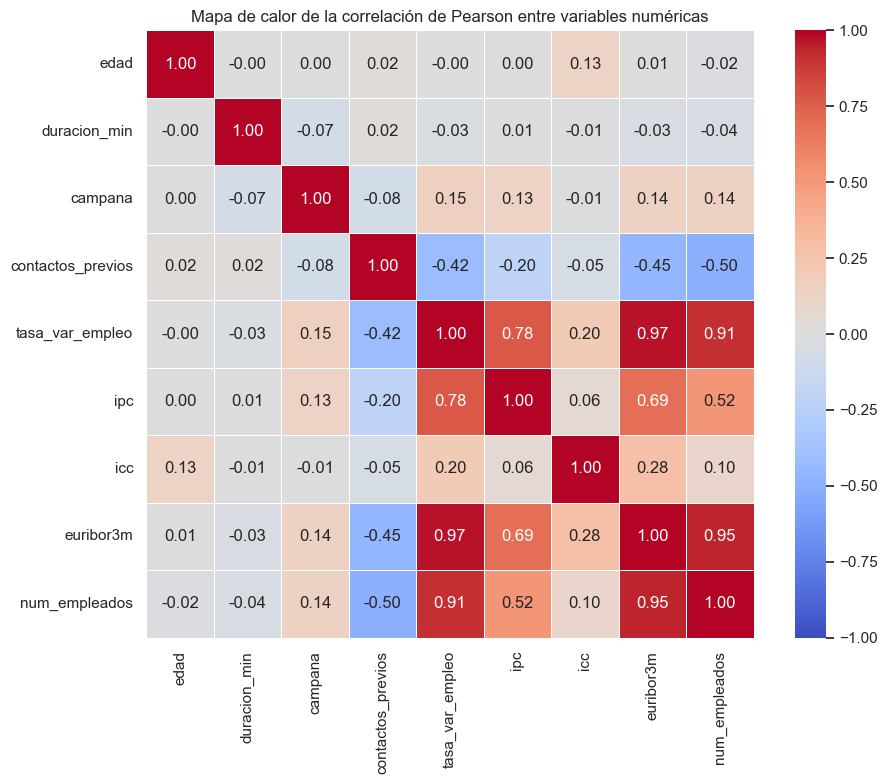

Gráfico guardado en: output_images\07_mapa_calor_correlacion.png

Pares con mayor correlación (en valor absoluto):
          variable_1       variable_2     r  r_absoluto
0    tasa_var_empleo        euribor3m  0.97        0.97
1          euribor3m    num_empleados  0.94        0.94
2    tasa_var_empleo    num_empleados  0.91        0.91
3    tasa_var_empleo              ipc  0.78        0.78
4                ipc        euribor3m  0.69        0.69
5                ipc    num_empleados  0.52        0.52
6  contactos_previos    num_empleados -0.50        0.50
7  contactos_previos        euribor3m -0.46        0.46
8  contactos_previos  tasa_var_empleo -0.42        0.42
9                icc        euribor3m  0.28        0.28

Pares con correlación absoluta ≥ 0.8 (posible colinealidad):
        variable_1     variable_2    r  r_absoluto
0  tasa_var_empleo      euribor3m 0.97        0.97
1        euribor3m  num_empleados 0.94        0.94
2  tasa_var_empleo  num_empleados 0.91        0.91


In [34]:
matriz_correlacion = df[variables_relacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Mapa de calor de la correlación de Pearson entre variables numéricas")
guardar_figura("07_mapa_calor_correlacion.png")

pares = []
for i, var1 in enumerate(variables_relacion):
    for var2 in variables_relacion[i + 1:]:
        pares.append({"variable_1": var1, "variable_2": var2, "r": matriz_correlacion.loc[var1, var2]})
pares = pd.DataFrame(pares)
pares["r_absoluto"] = pares["r"].abs()
pares = pares.sort_values("r_absoluto", ascending=False).reset_index(drop=True)

print("\nPares con mayor correlación (en valor absoluto):")
print(pares.head(10).round(3))
print("\nPares con correlación absoluta ≥ 0.8 (posible colinealidad):")
print(pares[pares["r_absoluto"] >= 0.8].round(3))

**Observaciones de la correlación**

- **Colinealidad fuerte entre indicadores macroeconómicos.** Tres pares superan el umbral de 0.8:
  - `tasa_var_empleo` y `euribor3m`: **r = 0.97** (positiva casi perfecta).
  - `euribor3m` y `num_empleados`: **r = 0.94**.
  - `tasa_var_empleo` y `num_empleados`: **r = 0.91**.

  Estas tres variables se mueven prácticamente juntas: describen el mismo ciclo económico, de expansión antes de la crisis y de contracción después. Contienen información redundante, y en una etapa posterior convendría no utilizarlas todas a la vez.
- **Relaciones moderadas:** `ipc` se asocia con `tasa_var_empleo` (r = 0.78) y con `euribor3m` (r = 0.69). `contactos_previos` tiene una correlación negativa moderada con `num_empleados` (r = −0.50), `euribor3m` (−0.46) y `tasa_var_empleo` (−0.42), coherente con lo observado en la covarianza.
- **Relaciones débiles o nulas:** `icc` apenas se relaciona con `euribor3m` (r = 0.28). La confianza del consumidor aporta información distinta a la del resto de indicadores. `edad`, `duracion_min` y `campana` tienen correlaciones cercanas a 0 con casi todas las demás variables.


#### 4.b.3 Boxplots comparativos según la suscripción

Se compara la distribución de las variables numéricas entre los clientes que suscribieron y los que no, mediante boxplots lado a lado.

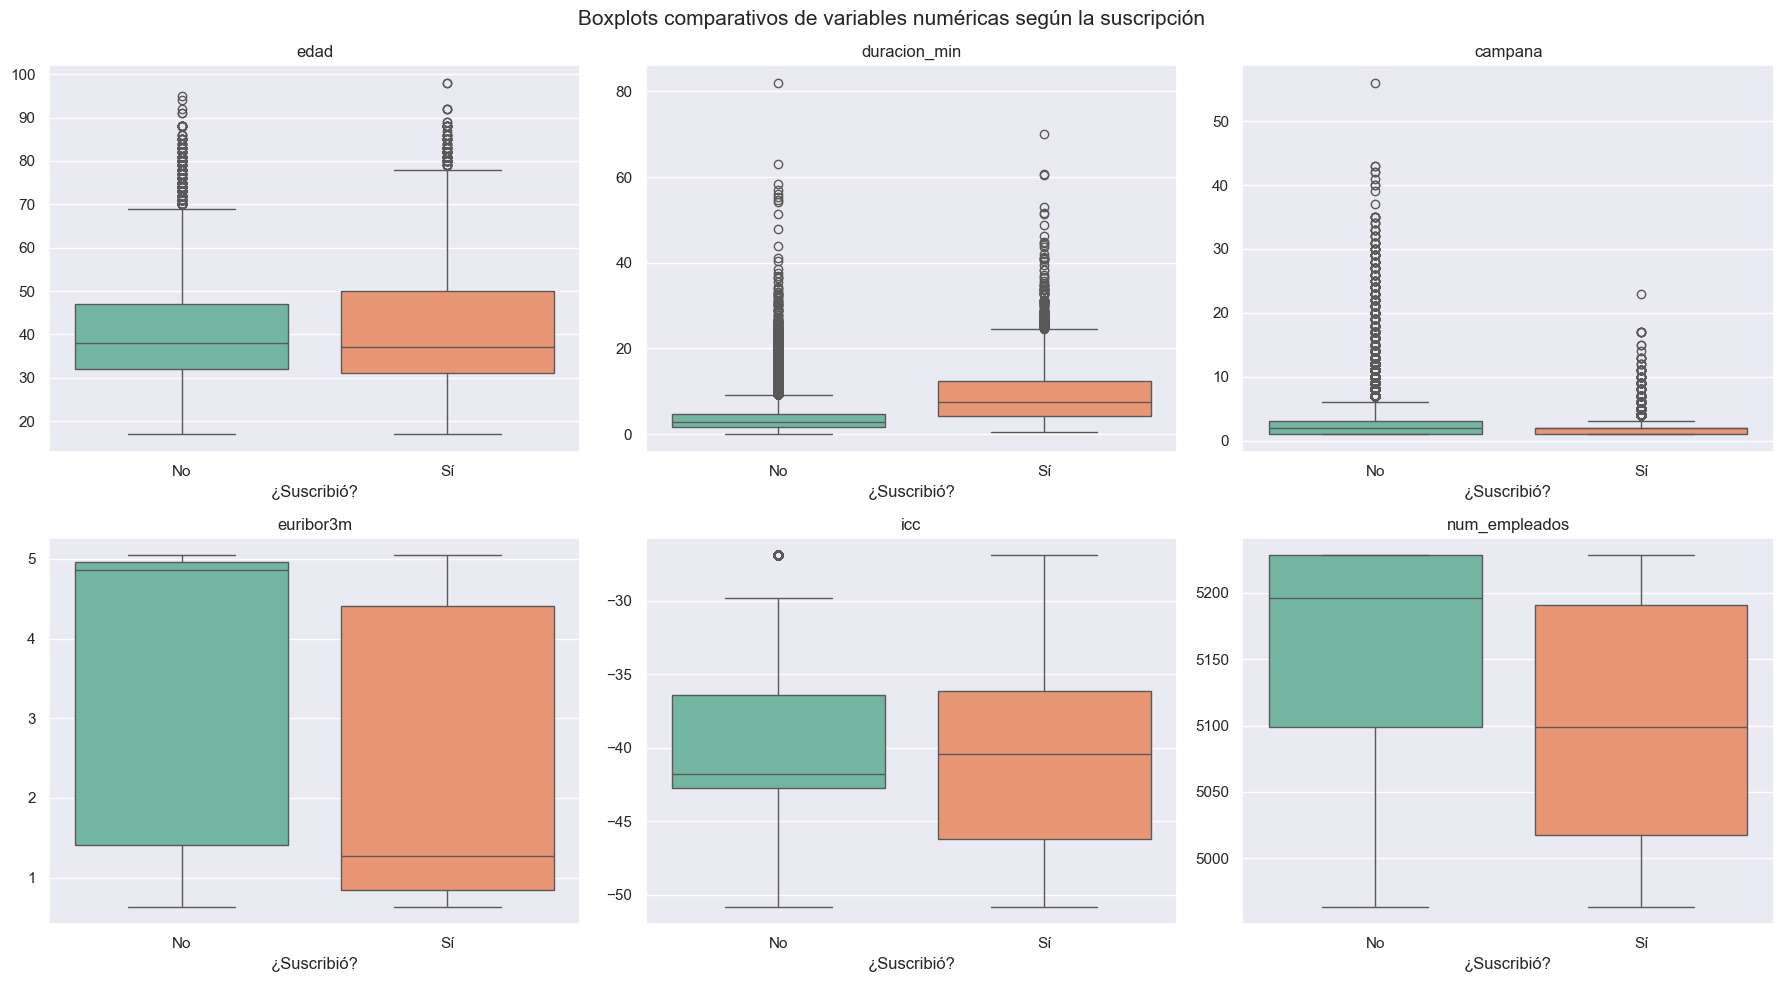

Gráfico guardado en: output_images\08_boxplots_por_suscripcion.png

Medidas por grupo:
                       media  mediana       q1       q3
variable      grupo                                    
edad          No       39.91    38.00    32.00    47.00
              Sí       40.91    37.00    31.00    50.00
duracion_min  No        3.68     2.73     1.58     4.65
              Sí        9.22     7.48     4.22    12.36
campana       No        2.63     2.00     1.00     3.00
              Sí        2.05     2.00     1.00     2.00
euribor3m     No        3.81     4.86     1.40     4.96
              Sí        2.12     1.27     0.85     4.41
icc           No      -40.59   -41.80   -42.70   -36.40
              Sí      -39.79   -40.40   -46.20   -36.10
num_empleados No    5,176.17 5,195.80 5,099.10 5,228.10
              Sí    5,095.12 5,099.10 5,017.50 5,191.00


In [38]:
variables_comparar = ["edad", "duracion_min", "campana", "euribor3m", "icc", "num_empleados"]
orden_objetivo = ["No", "Sí"]

fig, ejes = plt.subplots(2, 3, figsize=(18, 10))
for eje, col in zip(ejes.flatten(), variables_comparar):
    sns.boxplot(x=df["suscribio"], y=df[col], hue=df["suscribio"], order=orden_objetivo,
                hue_order=orden_objetivo, palette="Set2", legend=False, ax=eje)
    eje.set_title(f"{col}")
    eje.set_xlabel("¿Suscribió?")
    eje.set_ylabel('')
plt.suptitle("Boxplots comparativos de variables numéricas según la suscripción", fontsize=15)
guardar_figura("08_boxplots_por_suscripcion.png")

filas = []
for col in variables_comparar:
    for grupo in orden_objetivo:
        serie = df.loc[df["suscribio"] == grupo, col]
        filas.append({"variable": col, "grupo": grupo, "media": serie.mean(), "mediana": serie.median(),
                      "q1": serie.quantile(0.25), "q3": serie.quantile(0.75)})
print("\nMedidas por grupo:")
print(pd.DataFrame(filas).set_index(["variable", "grupo"]).round(2))

**Análsiis de boxplots comparativos**

- **`duracion_min`**: es la diferencia más marcada, los que se suscribieron tienen una mediana de **7.48 minutos** frente a **2.73** de quienes no lo hicieron y el primer cuartil de los que suscriben (4.22 min) casi coincide con el tercer cuartil de los que no (4.65 min). Las conversaciones que terminan en venta son mucho más largas. Esta relación **no puede usarse para priorizar clientes antes de llamar**, porque la duración solo se conoce después de la llamada, pero sí orienta la gestión: mantener la conversación es una condición para concretar la venta.
- **`euribor3m`**: los clientes que suscribieron fueron contactados con una Euribor mediana de **1.27%**, frente a **4.86%** en los que no suscribieron, además la aceptación se concentra en el periodo de tasas bajas, coherente con el estudio original: tras la crisis, la preferencia por el ahorro seguro aumentó.
- **`num_empleados`**: tiene el mismo patrón, la mediana es 5,099 entre quienes suscriben y 5,196 entre quienes no, también notamos que los periodos de menor empleo coinciden con mayor aceptación.
- **`campana`**: la mediana es 2 contactos en ambos grupos, pero el tercer cuartil baja de 3 (no suscriben) a 2 (suscriben) y la media de 2.63 a 2.05, de ello deducimos que más insistencia no se traduce en más ventas.
- **`edad`**: medianas similares (37 y 38 años), pero la caja de quienes suscriben es más amplia, con un tercer cuartil de 50 años frente a 47, por ende los clientes mayores tienen más presencia entre quienes aceptan.
- **`icc`**: diferencias pequeñas en la mediana (−40.4 frente a −41.8), aunque los que suscriben tienen un primer cuartil más bajo (−46.2), de ello observamos que parte de las suscripciones ocurre en meses de confianza muy baja.

#### 4.b.4 Mes de contacto y confianza del consumidor

Se explora si la relación entre el mes de contacto y la aceptación coincide con cambios en el índice de confianza del consumidor. Para ello se combinan boxplots del índice por mes con la tasa de aceptación mensual.

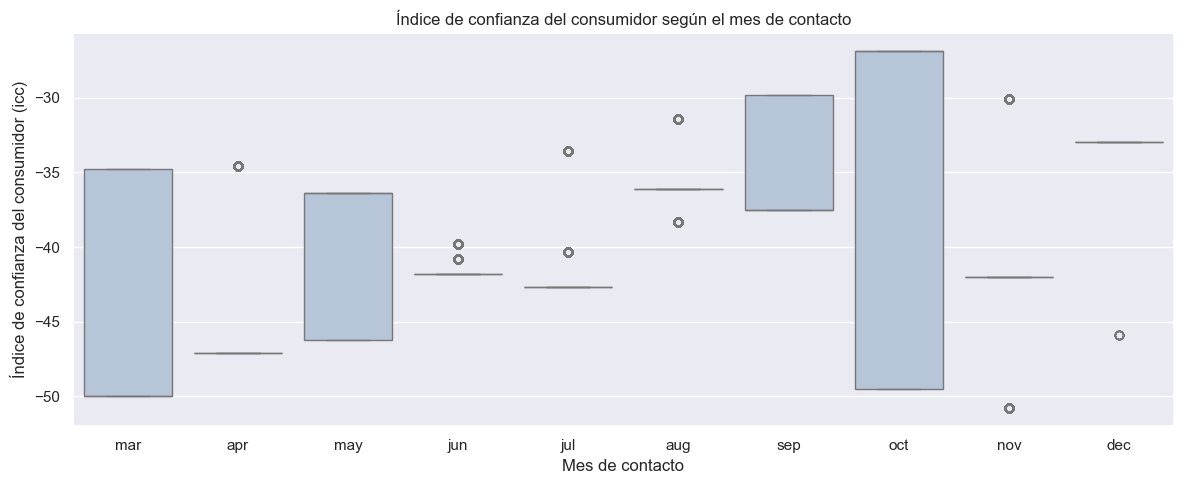

Gráfico guardado en: output_images\09_confianza_consumidor_por_mes.png

Contactos, tasa de aceptación y mediana del icc por mes:
     contactos  suscripciones  tasa_aceptacion_%  icc_mediana  pct_contactos
mes                                                                         
mar        546            276              50.55       -50.00           1.33
apr       2631            539              20.49       -47.10           6.39
may      13767            886               6.44       -36.40          33.43
jun       5318            559              10.51       -41.80          12.92
jul       7169            648               9.04       -42.70          17.41
aug       6176            655              10.61       -36.10          15.00
sep        570            256              44.91       -37.50           1.38
oct        717            315              43.93       -26.90           1.74
nov       4100            416              10.15       -42.00           9.96
dec        182          

In [39]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df["mes"], y=df["icc"], color="lightsteelblue")
plt.title("Índice de confianza del consumidor según el mes de contacto")
plt.xlabel("Mes de contacto")
plt.ylabel("Índice de confianza del consumidor (icc)")
guardar_figura("09_confianza_consumidor_por_mes.png")

aceptacion_mes = tasa_aceptacion(df, "mes").drop("Total")
aceptacion_mes["icc_mediana"] = [df.loc[df["mes"] == m, "icc"].median() for m in aceptacion_mes.index]
aceptacion_mes["pct_contactos"] = 100 * aceptacion_mes["contactos"] / len(df)
print("\nContactos, tasa de aceptación y mediana del icc por mes:")
print(aceptacion_mes.round(2))

**Análisis del mes de contacto y confianza del consumidor**

- **Relación inversa entre volumen de contactos y aceptación.** Mayo concentra el 33.43% de los contactos pero tiene la **tasa más baja: 6.44%**. En cambio, los meses con poca actividad tienen tasas muy altas: marzo (**50.55%**), diciembre (**48.90%**), septiembre (**44.91%**) y octubre (**43.93%**), todos con menos del 2% de los contactos.
- **Confianza del consumidor por mes:** el boxplot muestra que cada mes tiene valores de `icc` muy concentrados porque es un indicador mensual, además los meses de alta aceptación no comparten un mismo nivel de confianza, por ejemplo: marzo (−50.0) y abril (−47.1) tienen la confianza **más baja**, mientras que octubre (−26.9) tiene la **más alta** y la confianza del consumidor por sí sola no explica la diferencia entre meses.

- **Nota:** la alta aceptación de los meses con pocos contactos puede reflejar que en esos periodos la campaña se dirigió a clientes más seleccionados mientras que mayo parece corresponder a un contacto masivo, aunque no podemos asegurar esto ya que el dataset no permite confirmar esta explicación, por lo que queda como hipótesis.
- **Implicancia:** concentrar un tercio de las llamadas en un mes de baja conversión eleva el costo por depósito captado. Distribuir el esfuerzo y replicar la forma de trabajo de los meses de alta conversión es una línea de mejora a evaluar.

#### 4.b.5 Histogramas por categoría

Se superponen los histogramas de cada grupo de la variable objetivo y como el grupo que no suscribió es casi ocho veces más grande, cada histograma se normaliza por separado (densidad), de modo que se comparan las **formas** de las distribuciones y no sus tamaños.

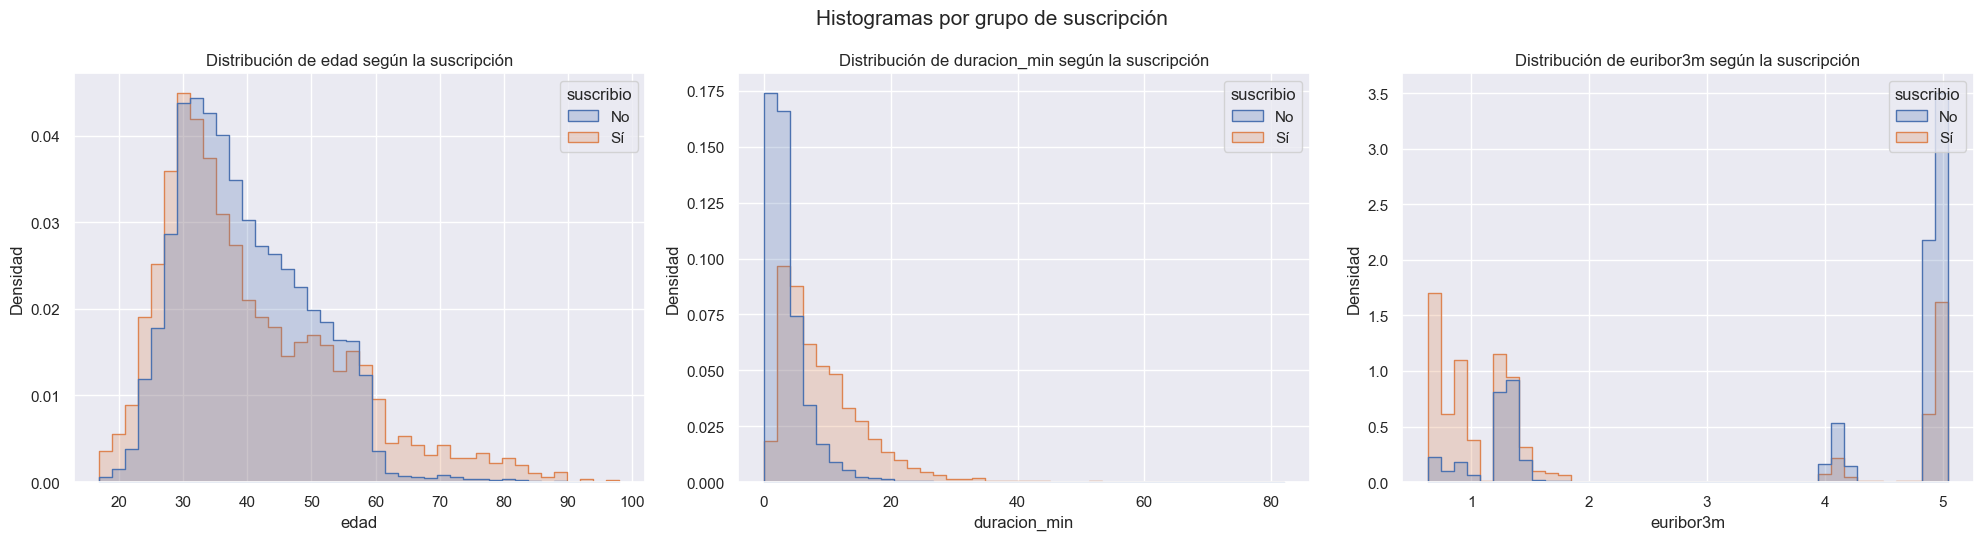

Gráfico guardado en: output_images\10_histogramas_por_suscripcion.png

edad:
  No  media =    39.91 | mediana =    38.00 | P10 =    29.00 | P90 =    54.00
  Sí  media =    40.91 | mediana =    37.00 | P10 =    26.00 | P90 =    60.00

duracion_min:
  No  media =     3.68 | mediana =     2.73 | P10 =     0.92 | P90 =     7.45
  Sí  media =     9.22 | mediana =     7.48 | P10 =     2.82 | P90 =    17.84

euribor3m:
  No  media =     3.81 | mediana =     4.86 | P10 =     1.27 | P90 =     4.96
  Sí  media =     2.12 | mediana =     1.27 | P10 =     0.71 | P90 =     4.96

Tasa de aceptación según el nivel de la Euribor:
               contactos  suscripciones  tasa_aceptacion_%
nivel_euribor                                             
Euribor < 3%       13494           3300              24.46
Euribor >= 3%      27682           1339               4.84
Total              41176           4639              11.27


In [40]:
variables_hist = ["edad", "duracion_min", "euribor3m"]

fig, ejes = plt.subplots(1, 3, figsize=(20, 5.5))
for eje, col in zip(ejes, variables_hist):
    sns.histplot(data=df, x=col, hue="suscribio", hue_order=orden_objetivo, bins=40,
                 stat="density", common_norm=False, element="step", ax=eje)
    eje.set_title(f"Distribución de {col} según la suscripción")
    eje.set_xlabel(col)
    eje.set_ylabel("Densidad")
plt.suptitle("Histogramas por grupo de suscripción", fontsize=15)
guardar_figura("10_histogramas_por_suscripcion.png")

for col in variables_hist:
    print(f"\n{col}:")
    for grupo in orden_objetivo:
        serie = df.loc[df["suscribio"] == grupo, col]
        print(f"  {grupo:<3} media = {serie.mean():8.2f} | mediana = {serie.median():8.2f} | "
              f"P10 = {serie.quantile(0.10):8.2f} | P90 = {serie.quantile(0.90):8.2f}")

print("\nTasa de aceptación según el nivel de la Euribor:")
nivel_euribor = pd.Series(np.where(df["euribor3m"] < 3, "Euribor < 3%", "Euribor >= 3%"),
                          index=df.index, name="nivel_euribor")
print(tasa_aceptacion(df.assign(nivel_euribor=nivel_euribor), "nivel_euribor").round(2))

**Interpretación: histogramas por grupo**

- **`edad`**: las formas son parecidas en el centro (medianas de 37 y 38 años) pero la distribución de quienes suscriben es **más ancha en los extremos**, por otro lado su percentil 10 es 26 años (frente a 29) y su percentil 90, 60 años (frente a 54), deducimos qu los clientes jóvenes y los mayores de 60 tienen más peso relativo entre quienes aceptan.
- **`duracion_min`**: la distribución de quienes no suscriben se concentra en los primeros minutos (percentil 90 = 7.45 min) y la de quienes suscriben está desplazada hacia la derecha, note que su percentil 10 es 2.82 min y su percentil 90, 17.84 min, lo que indica que casi no hay suscripciones en llamadas muy cortas.
- **`euribor3m`**: Entre los no suscritos la masa se concentra en la zona de tasas altas (mediana de 4.86%), respecto a los suscritos los datos se concentran en la zona de tasas bajas (mediana de 1.27%). La tabla de apoyo lo confirma con una **Euribor menor a 3% la tasa de aceptación es 24.46%** y con una Euribor de 3% o más es solo **4.84%**, cinco veces menor.

**Implicancia:** el contexto de tasas de interés bajas coincide con una propensión al ahorro mucho mayor, recordando que para planificar campañas el entorno económico es una variable tan importante como el perfil del cliente y coincide con la tendencia que proviene de un periodo histórico concreto (2008-2010).

#### 4.b.6 Gráficos de barras agrupadas y tablas cruzadas

Las barras agrupadas muestran la frecuencia de cada categoría separada por la variable objetivo y como el grupo "No" domina en todas las categorías, cada gráfico se acompaña de una tabla cruzada con la **tasa de aceptación** (frecuencia relativa por fila), que es la medida comparable entre categorías.

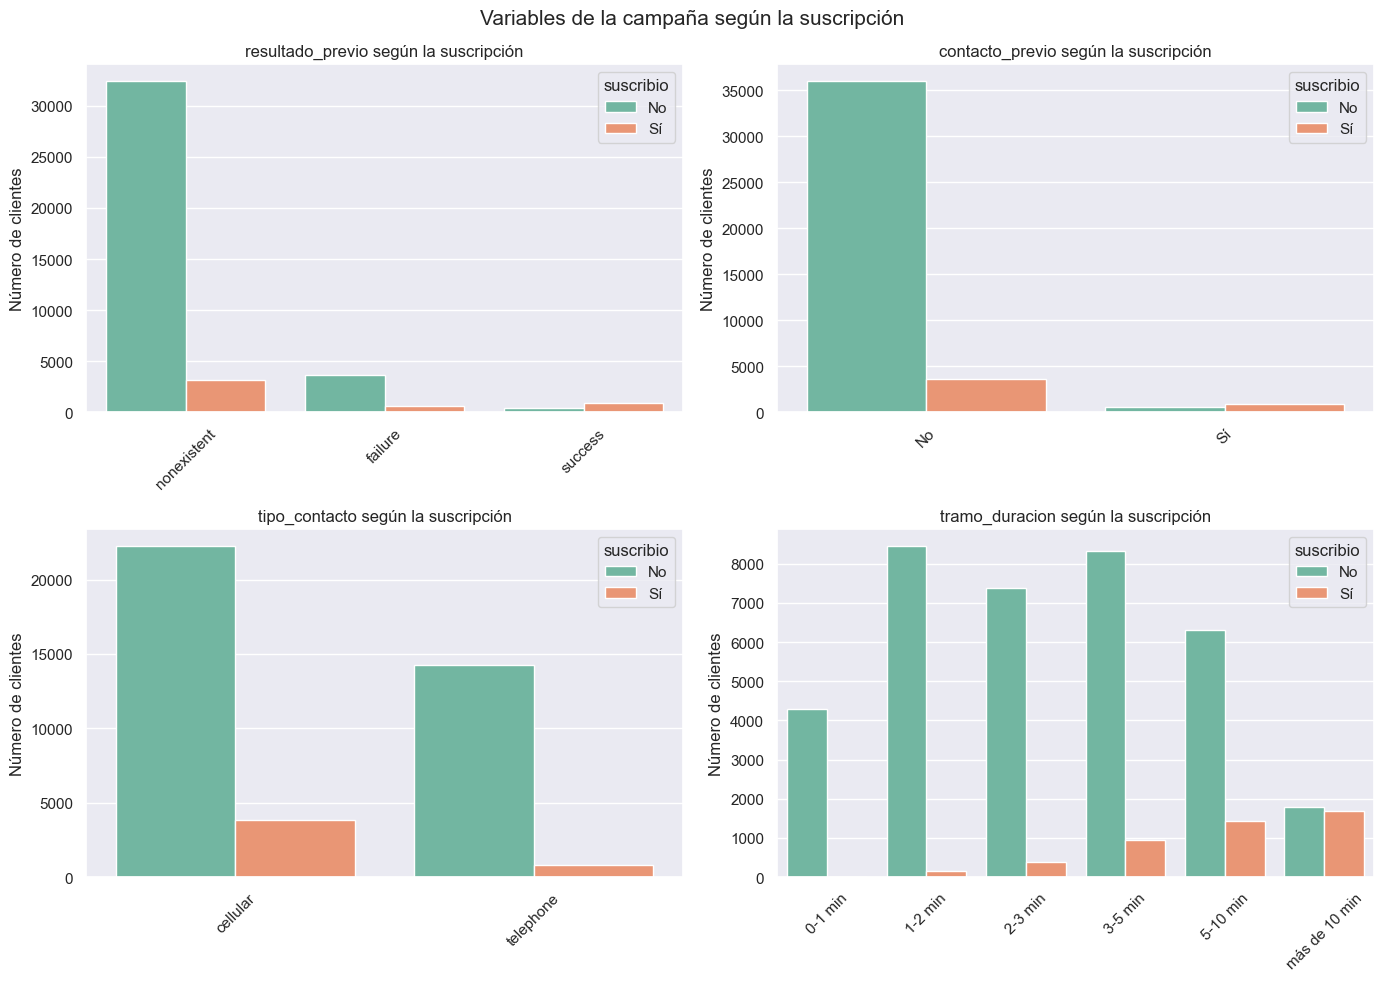

Gráfico guardado en: output_images\11_barras_agrupadas_campana.png

Tasa de aceptación por resultado_previo:
                  contactos  suscripciones  tasa_aceptacion_%
resultado_previo                                             
failure                4252            605              14.23
nonexistent           35551           3140               8.83
success                1373            894              65.11
Total                 41176           4639              11.27

Tasa de aceptación por contacto_previo:
                 contactos  suscripciones  tasa_aceptacion_%
contacto_previo                                             
No                   39661           3672               9.26
Sí                    1515            967              63.83
Total                41176           4639              11.27

Tasa de aceptación por tipo_contacto:
               contactos  suscripciones  tasa_aceptacion_%
tipo_contacto                                             
cellular        

In [41]:
def barras_agrupadas(datos, columnas, nombre_archivo, titulo, filas, cols):
    fig, ejes = plt.subplots(filas, cols, figsize=(7 * cols, 5 * filas))
    ejes = ejes.flatten()
    for eje, col in zip(ejes, columnas):
        orden = (datos[col].cat.categories if datos[col].cat.ordered
                 else datos[col].value_counts().index)
        sns.countplot(data=datos, x=col, hue="suscribio", order=orden, hue_order=orden_objetivo,
                      palette="Set2", ax=eje)
        eje.set_title(f"{col} según la suscripción")
        eje.set_xlabel('')
        eje.set_ylabel("Número de clientes")
        eje.tick_params(axis="x", rotation=45)
    for eje in ejes[len(columnas):]:
        eje.set_visible(False)
    plt.suptitle(titulo, fontsize=15)
    guardar_figura(nombre_archivo)

    for col in columnas:
        print(f"\nTasa de aceptación por {col}:")
        print(tasa_aceptacion(datos, col).round(2))


barras_agrupadas(df, ["resultado_previo", "contacto_previo", "tipo_contacto", "tramo_duracion"],
                 "11_barras_agrupadas_campana.png", "Variables de la campaña según la suscripción", filas=2, cols=2)

**Análisis de barras agrupadas**

- **`resultado_previo`**: Los clientes con un **éxito previo aceptan en un 65.11%**, casi seis veces la tasa general, incluso un fracaso previo (14.23%) supera a los clientes sin campaña anterior (8.83%) esto es concluyente sobre que haber tenido contacto con el banco se asocia con mayor apertura.
- **`contacto_previo`**: los clientes con historial de contacto aceptan en un **63.83%**, frente a 9.26% de los que nunca fueron contactados, además en el gráfico de barras este grupo parece pequeño por su volumen (1,515 clientes) pero es el que más convierte.
- **`tipo_contacto`**: los contactos por celular convierten en un **14.74%**, casi el triple que los de teléfono fijo (5.23%).
- **`tramo_duracion`**: la tasa de aceptación crece de forma sostenida con la duración de **0.02%** en llamadas de hasta 1 minuto, 1.91% entre 1 y 2 minutos, 10.27% entre 3 y 5 minutos, 18.58% entre 5 y 10 minutos y **48.61%** por encima de 10 minutos. Respecto a las que están por debajo de los **3 minutos** la venta es muy improbable (5.11% o menos) entre 3 y 5 minutos la tasa se acerca a la media general y a partir de los **5 minutos** la supera con claridad, note que esta variable sería más util para orientar a los agentes del callcenter y no para seleccionar clientes antes de la llamada.

**Implicancia:** para priorizar clientes antes de contactarlos, la señal más útil disponible es el **historial de la relación** (resultado y existencia de contacto previo), seguida del tipo de teléfono.

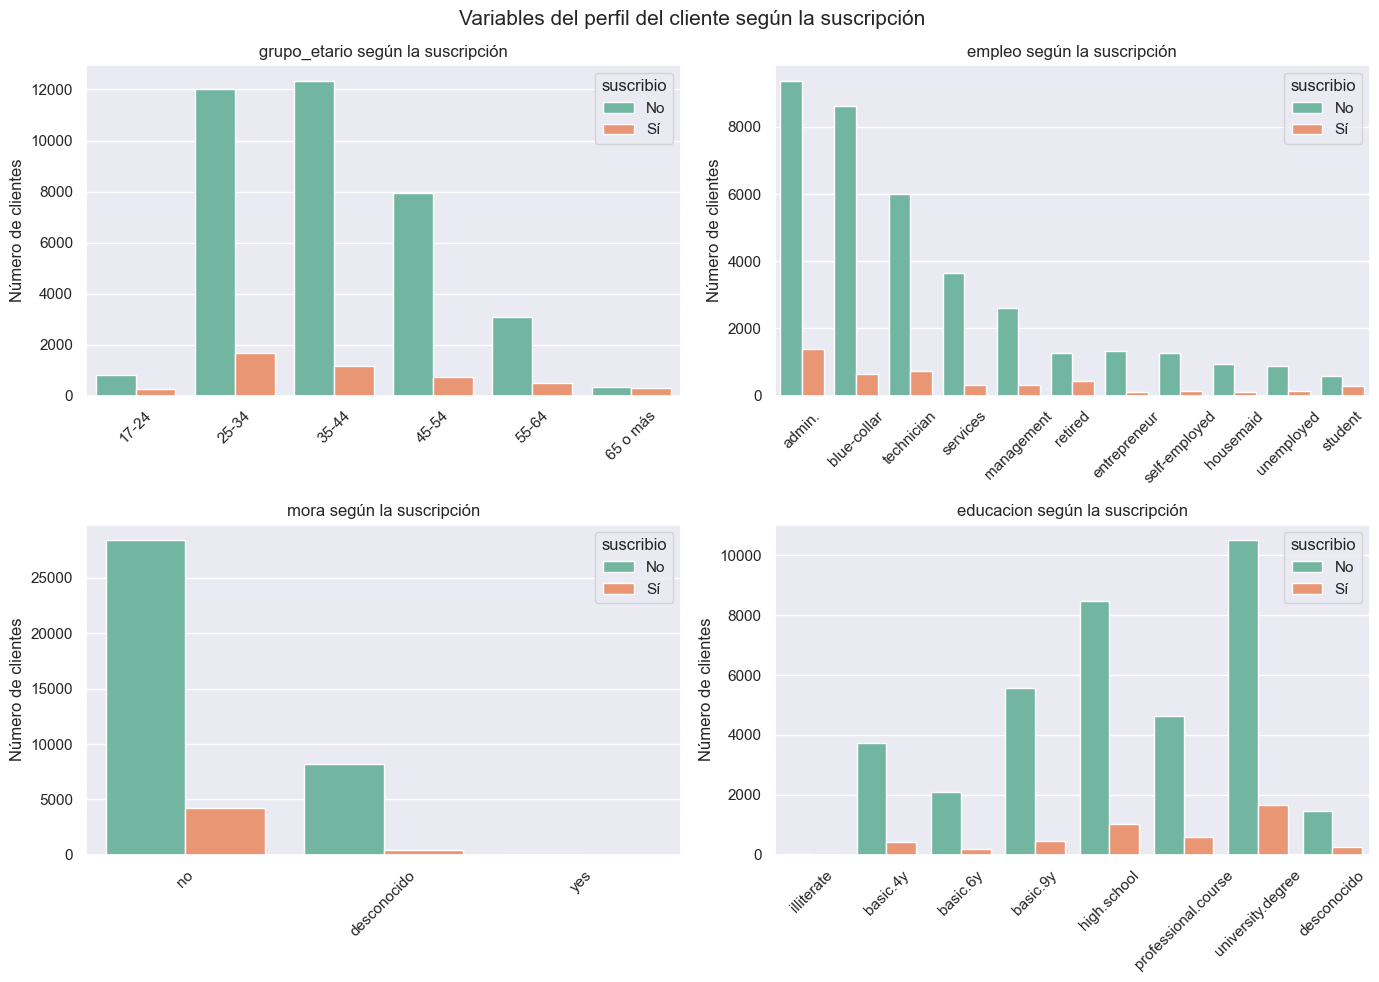

Gráfico guardado en: output_images\12_barras_agrupadas_perfil.png

Tasa de aceptación por grupo_etario:
              contactos  suscripciones  tasa_aceptacion_%
grupo_etario                                             
17-24              1067            256              23.99
25-34             13684           1666              12.17
35-44             13495           1168               8.66
45-54              8702            752               8.64
55-64              3566            484              13.57
65 o más            662            313              47.28
Total             41176           4639              11.27

Tasa de aceptación por empleo:
               contactos  suscripciones  tasa_aceptacion_%
empleo                                                    
admin.             10749           1388              12.91
blue-collar         9253            638               6.90
entrepreneur        1456            124               8.52
housemaid           1060            106        

In [42]:
barras_agrupadas(df, ["grupo_etario", "empleo", "mora", "educacion"],
                 "12_barras_agrupadas_perfil.png", "Variables del perfil del cliente según la suscripción", filas=2, cols=2)

**Análisis de las barras agrupadas del perfil de los clientes**

- **`grupo_etario`**: la tasa de aceptación es alta en los extremos, **47.28%** en clientes de 65 años o más y **23.99%** en los de 17 a 24, y mínima en los grupos centrales de 35-44 y 45-54 años (8.66% y 8.64%), y aunque precisamente los grupos centrales son los más contactados las campañas concentran su esfuerzo en los segmentos que menos convierten.
- **`empleo`**: los **estudiantes (31.43%)** y los **jubilados (25.26%)** tienen las tasas más altas, seguidos por desempleados (14.20%) y administrativos (12.91%). Los obreros (`blue-collar`, 6.90%) y el personal de servicios (8.14%) tienen las más bajas. Este resultado es coherente con el patrón por edad entre estudiantes y jubilados.
- **`mora`**: los clientes sin mora aceptan en un 12.88%, frente al 5.15% de aquellos cuyo dato es desconocido. La categoría `yes` (3 clientes, 0 suscripciones) es demasiado pequeña para interpretarse.
- **`educacion`**: entre las categorías con volumen notable la aceptación aumenta con el nivel educativo, por ejemplo: de 7.82% (`basic.9y`) a **13.72%** (`university.degree`), adicionalmente la categoría `desconocido` (14.51%) también supera la tasa general y `illiterate` (22.22%) no es concluyente porque tiene solo 18 clientes.

**Nota:** Según los patrones de conversion se debe reorientar parte del esfuerzo hacia jubilados, estudiantes y clientes con estudios superiores ya que esto podría mejorar la conversión, aunque cabe destacar que la asociación entre perfil y aceptación es descriptiva y no garantiza que contactar más a esos grupos mantenga las mismas tasas.

#### 4.b.7 Diagramas de dispersión

Se analizan siete pares de variables numéricas, coloreando los puntos según la suscripción. Los cinco primeros pares corresponden a los indicadores macroeconómicos y los dos últimos, a variables descriptivas de las llamadas.

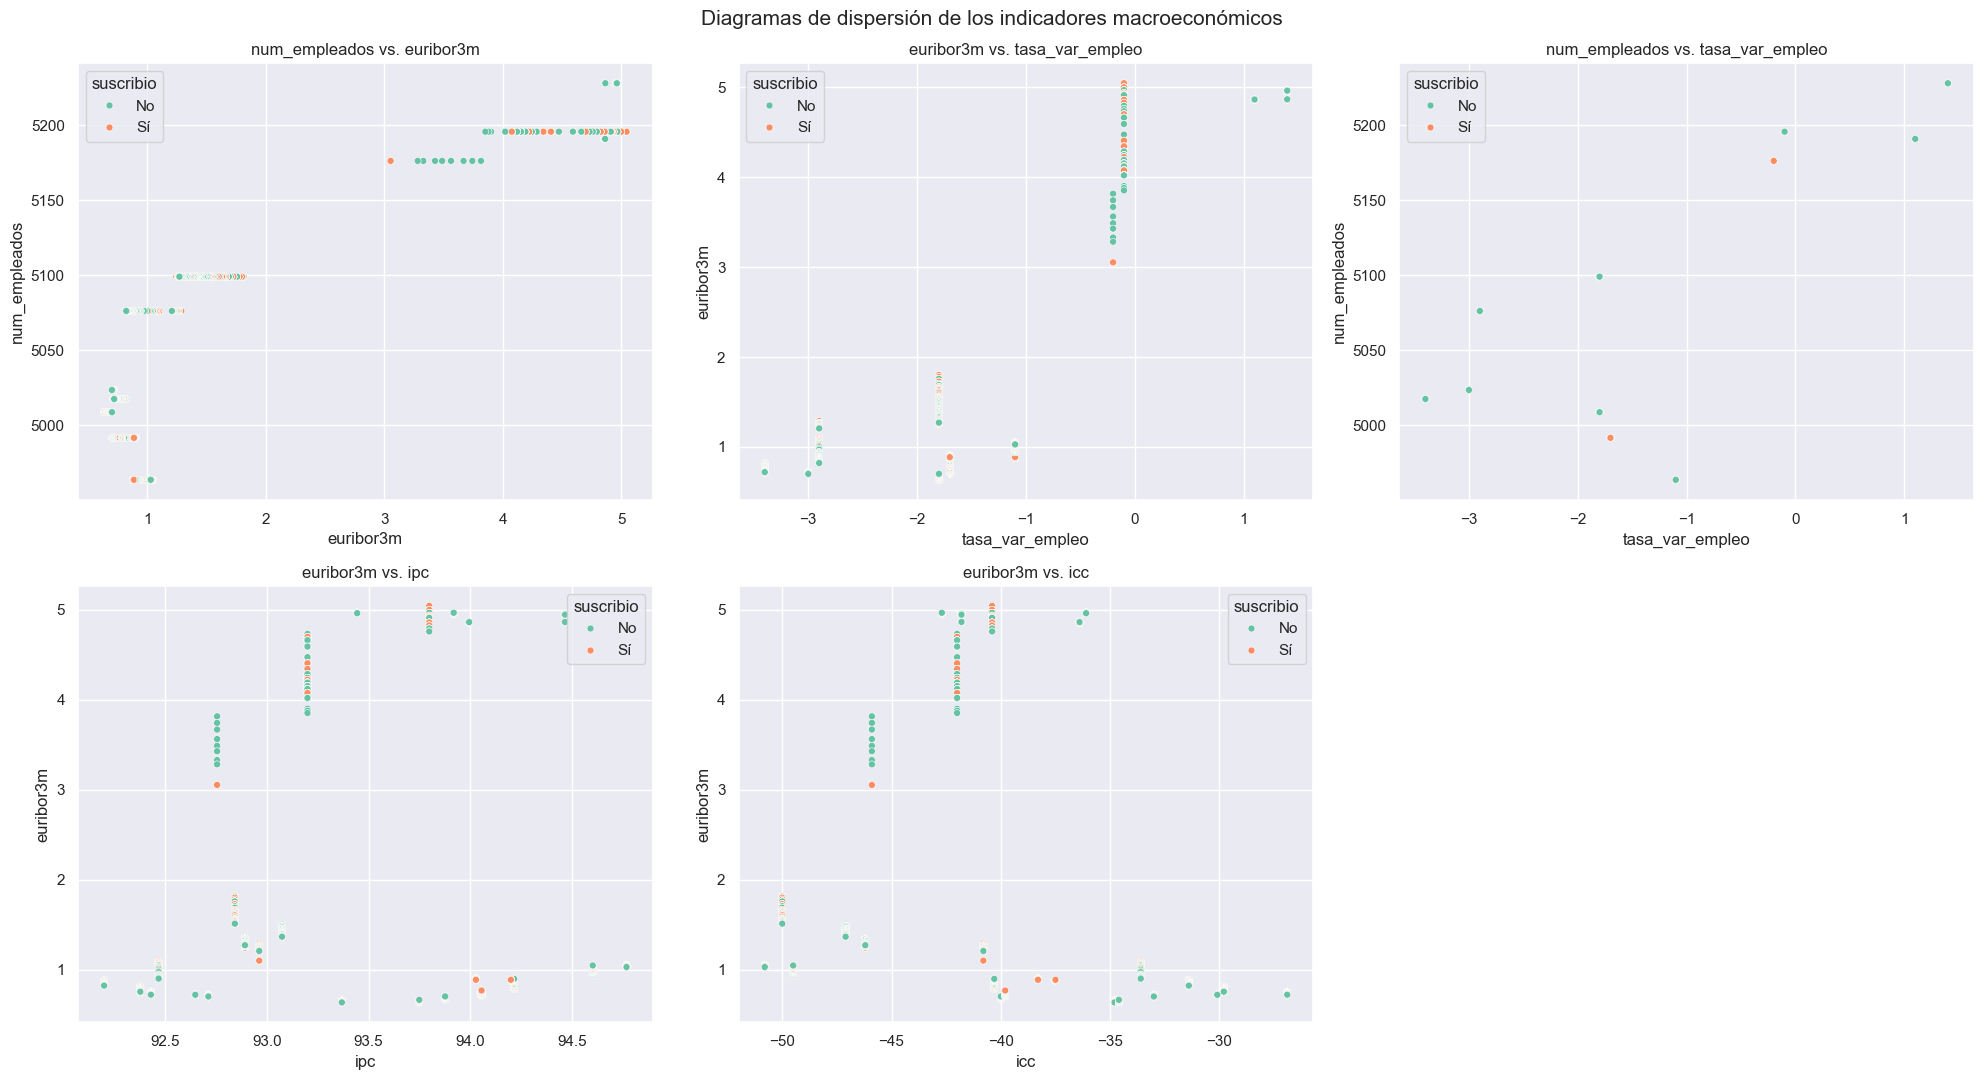

Gráfico guardado en: output_images\13_dispersion_indicadores_macroeconomicos.png

Correlación de Pearson y número de combinaciones distintas por par:
  num_empleados  vs euribor3m       r =  0.945 | combinaciones distintas = 350
  euribor3m      vs tasa_var_empleo r =  0.972 | combinaciones distintas = 350
  num_empleados  vs tasa_var_empleo r =  0.907 | combinaciones distintas = 11
  euribor3m      vs ipc             r =  0.688 | combinaciones distintas = 375
  euribor3m      vs icc             r =  0.278 | combinaciones distintas = 375


In [45]:
pares_macro = [("euribor3m", "num_empleados"), ("tasa_var_empleo", "euribor3m"),
               ("tasa_var_empleo", "num_empleados"), ("ipc", "euribor3m"), ("icc", "euribor3m")]

fig, ejes = plt.subplots(2, 3, figsize=(20, 11))
ejes = ejes.flatten()
for eje, (x, y) in zip(ejes, pares_macro):
    sns.scatterplot(data=df, x=x, y=y, hue="suscribio", hue_order=orden_objetivo, palette="Set2",
                    alpha=1, s=25, ax=eje)
    eje.set_title(f"{y} vs. {x}")
ejes[-1].set_visible(False)
plt.suptitle("Diagramas de dispersión de los indicadores macroeconómicos", fontsize=15)
guardar_figura("13_dispersion_indicadores_macroeconomicos.png")

print("\nCorrelación de Pearson y número de combinaciones distintas por par:")
for x, y in pares_macro:
    r = df[x].corr(df[y])
    combinaciones = len(df[[x, y]].drop_duplicates())
    print(f"  {y:<14} vs {x:<15} r = {r:6.3f} | combinaciones distintas = {combinaciones}")

**Análisis de diagramas de dispersión macroeconómicos**

1. **`num_empleados` vs. `euribor3m` (r = 0.945):** Tienen una relación lineal positiva muy fuerte donde los puntos forman **franjas horizontales** porque `num_empleados` es trimestral y dentro de cada trimestre el empleo es constante mientras Euribor varía día a día, además los puntos de quienes suscriben se concentran en la parte inferior izquierda, con bajo empleo y tasas bajas.
2. **`euribor3m` vs. `tasa_var_empleo` (r = 0.972):** Tienen la relación más fuerte del dataset, los puntos forman **columnas verticales** con una por cada valor trimestral de la tasa de variación del empleo, a partir de ello observamos que cuando el empleo crece, la Euribor es alta y cuando el empleo cae la tasa es baja.
3. **`num_empleados` vs. `tasa_var_empleo` (r = 0.907):** Aquí solo existen **11 combinaciones distintas**, ya que ambas variables son trimestrales y cada punto representa un trimestre completo con cientos de clientes superpuestos, note que la relación es positiva pero hay bastante incertidumbre ya que el calculo es sobre muy pocas combinaciones, repetidas miles de veces.
4. **`euribor3m` vs. `ipc` (r = 0.688):** Tienen relación positiva moderada con agrupamientos verticales, uno por cada valor mensual del IPC, y La asociación no es estrictamente lineal ya que hay meses de IPC alto con tasas bajas.
5. **`euribor3m` vs. `icc` (r = 0.278):** Tienen relación débil con los mismos niveles de Euribor aparecen niveles muy distintos de confianza del consumidor, lo que confirma que el `icc` aporta información útil.

**Conclusión:** 
- Los indicadores macroeconómicos se organizan en **grupos discretos** (periodos) y no en nubes continuas. 
- La fuerte colinealidad entre `tasa_var_empleo`, `euribor3m` y `num_empleados` es real, pero proviene de pocos contextos económicos repetidos.
- Sucede que el valor del coeficiente de Pearson por sí solo no describe la estructura de los datos y fue imprescindible graficar.

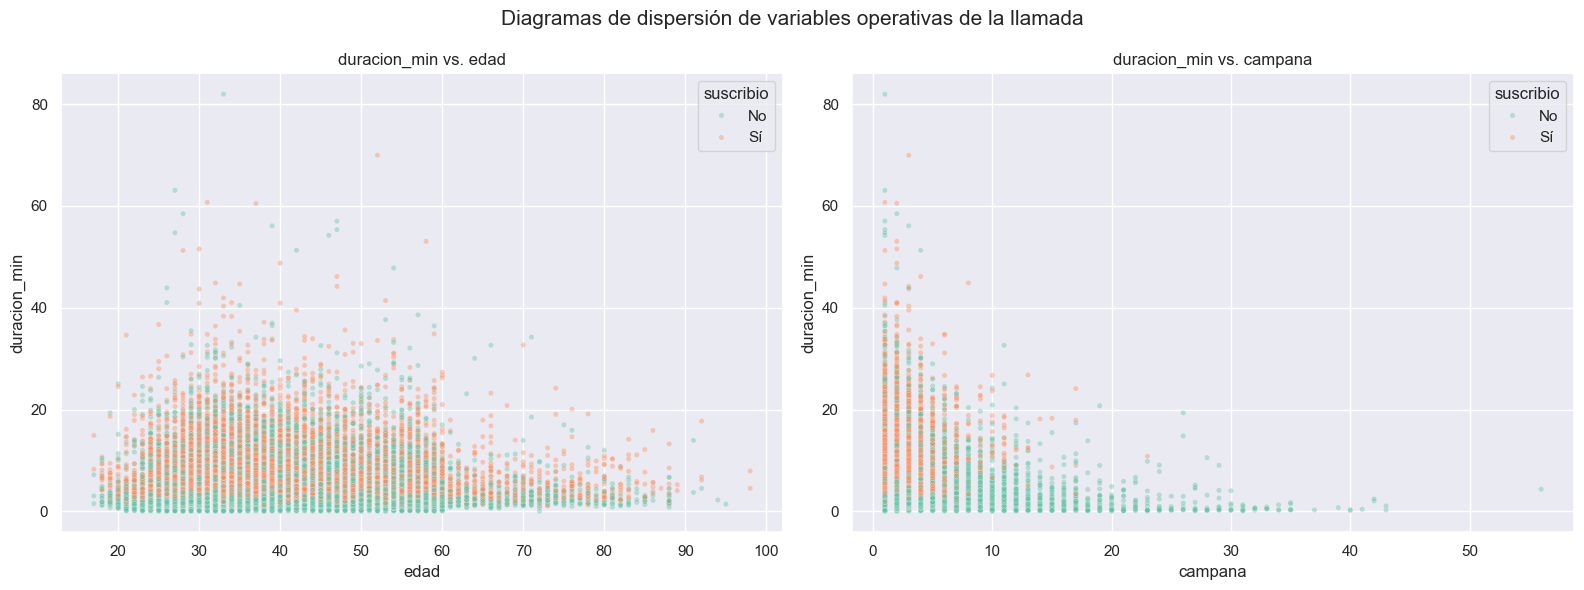

Gráfico guardado en: output_images\14_dispersion_variables_operativas.png

Correlación de Pearson por par:
  duracion_min vs edad: r = -0.001
  duracion_min vs campana: r = -0.072

Duración media (min) según el número de contactos en la campaña:
  1          n = 17,634 | duración media = 4.28 min | tasa de aceptación = 13.04%
  2          n = 10,568 | duración media = 4.66 min | tasa de aceptación = 11.46%
  3          n =  5,340 | duración media = 4.50 min | tasa de aceptación = 10.75%
  4-5        n =  4,249 | duración media = 4.04 min | tasa de aceptación = 8.68%
  6-10       n =  2,516 | duración media = 3.61 min | tasa de aceptación = 6.32%
  más de 10  n =    869 | duración media = 2.60 min | tasa de aceptación = 3.11%


In [46]:
pares_operativos = [("edad", "duracion_min"), ("campana", "duracion_min")]

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))
for eje, (x, y) in zip(ejes, pares_operativos):
    sns.scatterplot(data=df, x=x, y=y, hue="suscribio", hue_order=orden_objetivo, palette="Set2",
                    alpha=0.4, s=15, ax=eje)
    eje.set_title(f"{y} vs. {x}")
plt.suptitle("Diagramas de dispersión de variables operativas de la llamada", fontsize=15)
guardar_figura("14_dispersion_variables_operativas.png")

print("\nCorrelación de Pearson por par:")
for x, y in pares_operativos:
    print(f"  {y} vs {x}: r = {df[x].corr(df[y]):.3f}")

print("\nDuración media (min) según el número de contactos en la campaña:")
tramos_campana = pd.cut(df["campana"], bins=[0, 1, 2, 3, 5, 10, df["campana"].max()],
                        labels=["1", "2", "3", "4-5", "6-10", "más de 10"])
for tramo in tramos_campana.cat.categories:
    sub = df[tramos_campana == tramo]
    print(f"  {tramo:<10} n = {len(sub):>6,} | duración media = {sub['duracion_min'].mean():.2f} min | "
          f"tasa de aceptación = {100 * (sub['suscribio'] == 'Sí').mean():.2f}%")

**Observaciones sobre los diagramas de dispersión de variables operativas (las que describen las llamadas)**

6. **`duracion_min` vs. `edad` (r = −0.001):** La duración de la llamada es similar en todas las edades y los puntos de suscripción (duraciones altas) aparecen en todos los rangos de edad, y por el valor de la correlación no hay relación lineal en este caso.
7. **`duracion_min` vs. `campana` (r = −0.072):** Tienen una relación lineal débil y negativa, pero con un patrón intersante a medida que aumenta el número de contactos, las duraciones largas desaparecen. Los datos descriptivos lo cuantifica:
   - Con **1 contacto**, la duración media es de 4.28 minutos y la tasa de aceptación, **13.04%**.
   - Entre 6 y 10 contactos, la duración baja a 3.61 minutos y la aceptación, a 6.32%.
   - Con **más de 10 contactos**, la duración es de 2.60 minutos y la aceptación, solo **3.11%**.

**Implicancia:** insistir sobre un mismo cliente se asocia con conversaciones más cortas y con una aceptación cuatro veces menor. Este resultado respalda la asunción inicial sobre las llamadas, que tienen "insistencia excesiva" y se sugiere fijar un **límite de contactos por cliente** ya que a partir del tercer contacto la tasa de aceptación (10.75%) y está por debajo de la media general y continua cayendo.

Esto no es concluyente ya que como toda relación exploratoria, encontramos asociaciones y no pruebas que el exceso de llamadas sea la causa del rechazo.

### 4.c Conclusiones generales del EDA

#### Hallazgos a nivel univariado

1. **Desbalance de la variable objetivo:** solo el 11.27% de los contactos terminó en suscripción (ratio 1 : 7.88). La campaña actual invierte la mayor parte de su esfuerzo en clientes que no convierten.
2. **Calidad de los datos:** no hay `NaN` explícitos, pero sí valores `"unknown"`, sobre todo en `mora` (20.87%). El valor 999 de `dias_previos` indica "nunca contactado" (96.32% de los casos) y no una cantidad de días. Ambos se detectaron y trataron de forma justificada.
3. **Variables operativas muy asimétricas:** `duracion_min` y `campana` concentran sus valores en niveles bajos, con colas largas de atípicos que se conservaron por su valor de negocio.
4. **Campaña concentrada:** dos tercios de los contactos se dirigieron a clientes de 25 a 44 años, el 78.76% se realizó entre mayo y agosto, y el 96.32% fue a clientes sin historial previo.
5. **Indicadores macroeconómicos discretos:** toman pocos valores y describen mejor los periodos que las personas. La Euribor muestra dos regímenes, de tasas altas (alrededor de 5%) y bajas (alrededor de 1%).

#### Hallazgos a nivel multivariado

1. **Historial del cliente:** un éxito en una campaña previa se asocia con una tasa de aceptación del **65.11%** y cualquier contacto previo, con un **63.83%**, frente a 9.26% sin historial.
2. **Contexto económico:** con una Euribor menor a 3% la aceptación es de **24.46%**; con 3% o más, de **4.84%**. Los periodos de tasas y empleo bajos coinciden con una mayor preferencia por el ahorro seguro.
3. **Perfil:** la aceptación sigue una tendencia inicial alta, luego por la mediana baja y vuelve a subir, con 47.28% en clientes de 65 años o más y 23.99% entre 17 y 24 años donde destacan estudiantes (31.43%) y jubilados (25.26%), y aumenta con el nivel educativo.
4. **Canal e insistencia:** el celular convierte casi tres veces más que el teléfono fijo (14.74% frente a 5.23%). La aceptación cae de 13.04% con un contacto a 3.11% con más de diez.
5. **Estacionalidad:** mayo concentra un tercio de los contactos y tiene la tasa más baja (6.44%), mientras que marzo, septiembre, octubre y diciembre superan el 43%.
6. **Duración:** la aceptación sube de 0.02% en llamadas de hasta 1 minuto a 48.61% en llamadas de más de 10 minutos.

#### Colinealidad y posibles relaciones lineales

- Existe **colinealidad fuerte** entre `tasa_var_empleo`, `euribor3m` y `num_empleados` (r entre 0.91 y 0.97), y moderada con `ipc` (hasta 0.78). Estas variables contienen información redundante sobre el ciclo económico, por lo que bastaria seleccionar solo una de ellas como variable predictiva, por ejemplo `euribor3m`.
- `icc` tiene una relación débil con el resto (r = 0.28 con `euribor3m`) y aporta información complementaria.
- Las variables del cliente y de la llamada (`edad`, `duracion_min`, `campana`) no presentan relaciones lineales relevantes entre sí. El vínculo entre `campana` y `duracion_min` es no lineal y solo se aprecia al graficar.

#### Variables clave que aportaron valor al análisis. 

| Variables | Nota |
|---|---|
| `resultado_previo`, `contacto_previo`, `euribor3m` (o un indicador macroeconómico equivalente) | Presentan mayores diferencias en la tasa de aceptación y disponibles antes de realizar la llamada. |
| `edad` / `grupo_etario`, `empleo`, `tipo_contacto`, `mes`, `campana`, `mora`, `educacion` | Tienen diferencias claras entre categorías y utilidad para segmentar la campaña. |
| `dia_semana`, `estado_civil`, `vivienda`, `prestamo` | Poseen una distribución uniforme o diferencias pequeñas en la aceptación lo cual las hace poco informativas para predecir la suscripción. |
| `duracion` | Está muy asociada a la aceptación, pero solo se conoce después de la llamada por lo que incluirla como variable predictiva produciría fuga de información. |

#### Consideraciones finales

- Todas las relaciones identificadas son **asociaciones descriptivas**, no asumimos que la correlación implica causalidad, y varias diferencias (por ejemplo, entre meses) pueden deberse a cómo se seleccionó a los clientes en cada periodo.
- Los datos provienen de un periodo específico de 2008-2010 que corresponde a una crisis financiera europea, por lo que los patrones vinculados al contexto económico deben validarse antes de aplicarse a otros periodos.
- Como los hallazgos más importantes del EDA, sugeririamos tres acciones: **priorizar a los clientes con historial de contacto**, **limitar la insistencia** a pocos contactos por cliente y **planificar las campañas considerando el contexto de tasas de interés**. La siguiente etapa de modelamiento, deberá considerar el desbalance de clases y excluir la variable `duracion`.